In [72]:

# ============================================================
# FASE I. EXPLORACIÓN Y CARACTERIZACIÓN DEL DATASET
# ============================================================

print("====================================================")
print("FASE I. EXPLORACIÓN Y CARACTERIZACIÓN DEL DATASET")
print("====================================================")
print("Objetivo: comprender la estructura, calidad y distribución inicial del dataset enriquecido.")

# ============================================================
# PASO 1. CARGAR EL DATASET Y REVISAR SU ESTRUCTURA REAL
# Dataset TOP-K adaptativo
# ============================================================
!pip install -U kaleido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 1000)

# Nombre exacto del archivo Excel
file_path = "Dataset_integration_semantico_topk_final.xlsx"

df = pd.read_excel(file_path)

print("====================================================")
print("PASO 1. ESTRUCTURA GENERAL DEL DATASET")
print("====================================================")

print("Filas originales:", df.shape[0])
print("Columnas originales:", df.shape[1])

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\n====================================================")
print("IDENTIFICACIÓN DE ESTRUCTURA DEL DATASET")
print("====================================================")

# ------------------------------------------------------------
# 1. Detectar formato ancho clásico
# ------------------------------------------------------------

wide_microcause_columns = [
    col for col in df.columns
    if col.startswith("microcause_")
]

# ------------------------------------------------------------
# 2. Detectar formato TOP-K adaptativo
# ------------------------------------------------------------

topk_columns = [
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count"
]

available_topk_columns = [
    col for col in topk_columns
    if col in df.columns
]

print("Columnas formato ancho encontradas:", len(wide_microcause_columns))
print(wide_microcause_columns)

print("\nColumnas TOP-K encontradas:", len(available_topk_columns))
print(available_topk_columns)

print("\nInterpretación:")

if "microcause_1_id" in df.columns:
    print("El dataset está en formato ANCHO.")
    print("Cada fila representa un comentario.")
    print("Las microcausas están en columnas microcause_1, microcause_2 y microcause_3.")

elif set(topk_columns).issubset(set(df.columns)):
    print("El dataset está en formato TOP-K adaptativo.")
    print("Cada fila representa un comentario.")
    print("Las microcausas están almacenadas como listas en top_microcause_ids, top_microcause_names y top_microcause_scores.")
    print("La columna top_microcause_count indica cuántas microcausas fueron asignadas por comentario.")

else:
    print("El dataset no tiene una estructura de microcausas reconocida.")
    print("Debe revisarse si faltan columnas de microcausas o si tienen otro nombre.")

print("\n====================================================")
print("COLUMNAS CLAVE PARA EL EDA")
print("====================================================")

key_columns = [
    "repo",
    "issue_number",
    "comment_id",
    "comment_created_at",
    "comment_body_clean_final",
    "final_cause_for_analysis",
    "primary_microcause_id",
    "primary_microcause_name",
    "primary_similarity_score",
    "top_microcause_ids",
    "top_microcause_names",
    "top_microcause_scores",
    "top_microcause_count",
    "classification_status_topk",
    "microcause_confidence_level",
    "effects",
    "risks",
    "community_smells",
    "preventive_strategies",
    "corrective_strategies",
    "indicators",
    "metrics"
]

existing_key_columns = [
    col for col in key_columns
    if col in df.columns
]

missing_key_columns = [
    col for col in key_columns
    if col not in df.columns
]

print("Columnas clave existentes:", len(existing_key_columns))
print(existing_key_columns)

print("\nColumnas clave faltantes:", len(missing_key_columns))
print(missing_key_columns)

print("\nPrimeras filas:")
display(df.head())

FASE I. EXPLORACIÓN Y CARACTERIZACIÓN DEL DATASET
Objetivo: comprender la estructura, calidad y distribución inicial del dataset enriquecido.
PASO 1. ESTRUCTURA GENERAL DEL DATASET
Filas originales: 3761
Columnas originales: 53

Columnas disponibles:
['repo', 'issue_number', 'comment_id', 'comment_author', 'comment_created_at', 'comment_body_raw', 'comment_body_clean_final', 'true_code', 'evaluable', 'match', 'final_cause_code', 'final_cause_for_analysis', 'predicted_code', 'predicted_label', 'Code_cause_llm', 'predicted_label_llm', 'Confidence_llm', 'Confidence', 'Requires_revision', 'State_prediction', 'Priority_rule_applied', 'rule_changed_llm', 'macro_cause_clean', 'specific_cause_id', 'specific_cause_name', 'specific_cause_type', 'similarity_score', 'classification_status', 'preventive_strategies', 'effects', 'corrective_strategies', 'indicators', 'metrics', 'risks', 'community_smells', 'comment_length', 'primary_microcause_id', 'primary_microcause_name', 'primary_microcause_type'

,repo,issue_number,comment_id,comment_author,comment_created_at,comment_body_raw,comment_body_clean_final,true_code,evaluable,match,final_cause_code,final_cause_for_analysis,predicted_code,predicted_label,Code_cause_llm,predicted_label_llm,Confidence_llm,Confidence,Requires_revision,State_prediction,Priority_rule_applied,rule_changed_llm,macro_cause_clean,specific_cause_id,specific_cause_name,specific_cause_type,similarity_score,classification_status,preventive_strategies,effects,corrective_strategies,indicators,metrics,risks,community_smells,comment_length,primary_microcause_id,primary_microcause_name,primary_microcause_type,primary_similarity_score,top_microcause_ids,top_microcause_names,top_microcause_types,top_microcause_scores,top_microcause_count,classification_status_topk,debug_comment_text,debug_best_comment_score,debug_best_macro_score,debug_best_lex_bonus,debug_second_score,debug_score_gap,microcause_confidence_level
0,microsoft/vscode,291739,3821059210,RedCMD,2026-01-30T00:11:41Z,yea\nvscode doesnt close the document for 3min\nonly the editor \n\nbut I agree\nVSCode should clear diagnostics for documents that aren't open in...,yea\nvscode doesnt close the document for 3min\nonly the editor\n\nbut I agree\nVSCode should clear diagnostics for documents that aren't open in ...,NaN,False,NaN,C,"Technical complexity, compatibility, and system constraints",C,"Technical complexity, compatibility, and system constraints",C,"Technical complexity, compatibility, and system constraints",0.85,0.85,False,ACCEPTED,none,False,technical complexity compatibility and system constraints,COG-008_CompatibilityConstraints,Compatibility constraints,CongruenceCause,0.323665,mapped_low_confidence,• PS-021_CompatibilityImpactAnalysis\n• PS-026_CompatibilityManagement,• TEF-011_CompatibilityProblems\n• TEF-021_CompatibilityFailure,• CS-021_TargetedCompatibilityValidation,• IND-013_DocumentationCompleteness\n• IND-021_CompatibilityMentions,• MTR-013_DocumentationCoverage,• RSK-013_TechnicalMaintenanceRisk\n• RSK-021_BackwardCompatibilityRisk,• Socio-Technical Congruence Gap,159,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,CongruenceCause,0.279686,['COG-006_LackOfInterfaceClarification'],['Lack of Interface Clarification'],['CongruenceCause'],[0.279686],1,mapped_low_confidence,yea vscode doesnt close the document for 3min only the editor but I agree VSCode should clear diagnostics for documents that aren't open in an edi...,0.269447,0.371834,0.00,0.274235,0.005451,low
1,microsoft/vscode,291739,3823089917,jrieken,2026-01-30T10:52:09Z,Diagnostics are computed by extensions and pushed into VS Code. It's up to the extension to handle closing/reopening editors and updating diagnost...,Diagnostics are computed by extensions and pushed into VS Code. It's up to the extension to handle closing/reopening editors and updating diagnost...,NaN,False,NaN,C,"Technical complexity, compatibility, and system constraints",C,"Technical complexity, compatibility, and system constraints",C,"Technical complexity, compatibility, and system constraints",0.90,0.90,False,ACCEPTED,none,False,technical complexity compatibility and system constraints,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,CongruenceCause,0.324510,mapped_low_confidence,• PS-004_InterfaceClarificationWorkshops\n• PS-012_InterfaceDocumentationGuidelines\n• PS-013_CrossComponentReviewBoards\n• PS-026_CompatibilityMa...,• IEF-008_ResistanceToChange\n• TEF-009_WastedTimeAndResources,• CS-034_ResourceUseCorrection\n• STR-I-015_ChangeManagementTraining\n• STR-I-016_ChangeChampions,• IND-004_Responsibility_Overlap_Index,• MTR-006_Information_Disconnect_Index,• RSK-005_Documentation_Gaps_Risk,• Missing Link,383,COG-006_LackOfInterfaceClarification,Lack of Interface Clarification,CongruenceCause,0.342248,"['COG-006_LackOfInterfaceClarification', 'COG-011_SystemConfigurationConstraints']","['Lack of Interface Clarification', 'System configuration constraints']","['C

In [73]:
# ============================================================
# PASO 2. CALIDAD DEL DATASET
# ============================================================

print("====================================================")
print("PASO 2. CALIDAD Y COMPLETITUD")
print("====================================================")

print("\nValores nulos por columna:")
nulls = df.isnull().sum()

display(
    nulls[nulls > 0]
    .sort_values(ascending=False)
)

print("\nPorcentaje de valores nulos:")

null_pct = (
    df.isnull().mean()*100
)

display(
    round(
        null_pct[null_pct > 0]
        .sort_values(ascending=False),
        2
    )
)

# ============================================================
# ELIMINAR COLUMNAS VACÍAS HEREDADAS
# ============================================================

df = df.drop(
    columns=[
        "true_code",
        "match"
    ],
    errors="ignore"
)

print("Columnas eliminadas:")
print(["true_code", "match"])

print("\nNueva dimensión del dataset:")
print(df.shape)

PASO 2. CALIDAD Y COMPLETITUD

Valores nulos por columna:


,0
true_code,3761
match,3761



Porcentaje de valores nulos:


,0
true_code,100.0
match,100.0


Columnas eliminadas:
['true_code', 'match']

Nueva dimensión del dataset:
(3761, 51)


In [74]:
# ============================================================
# PASO 3. TIPOS DE DATOS Y FECHAS
# ============================================================

print("====================================================")
print("PASO 3. TIPOS DE DATOS Y FECHAS")
print("====================================================")

print("\nTipos de datos:")

display(
    df.dtypes
)

print("\nResumen de tipos:")

display(
    df.dtypes.value_counts()
)

# ------------------------------------------------------------
# Convertir fecha
# ------------------------------------------------------------

df["comment_created_at"] = pd.to_datetime(
    df["comment_created_at"],
    errors="coerce"
)

print("\nFecha mínima:")
print(df["comment_created_at"].min())

print("\nFecha máxima:")
print(df["comment_created_at"].max())

print("\nNúmero de comentarios con fecha válida:")
print(
    df["comment_created_at"]
    .notnull()
    .sum()
)

PASO 3. TIPOS DE DATOS Y FECHAS

Tipos de datos:


,0
repo,object
issue_number,int64
comment_id,int64
comment_author,object
comment_created_at,object
comment_body_raw,object
comment_body_clean_final,object
evaluable,bool
final_cause_code,object
final_cause_for_analysis,object



Resumen de tipos:


,count
object,35
float64,9
int64,4
bool,3



Fecha mínima:
2024-01-03 14:07:27+00:00

Fecha máxima:
2026-02-03 22:05:48+00:00

Número de comentarios con fecha válida:
3761


In [75]:
# ============================================================
# PASO 4. VALIDACIÓN DE LA UNIDAD DE ANÁLISIS
# ============================================================

print("====================================================")
print("PASO 4. VALIDACIÓN DE LA UNIDAD DE ANÁLISIS")
print("====================================================")

# ------------------------------------------------------------
# 4.1 Validar comentarios únicos
# ------------------------------------------------------------

total_rows = len(df)

unique_comments = df["comment_id"].nunique()

duplicated_comment_ids = df.duplicated(
    subset=["comment_id"]
).sum()

print("\nFilas totales del dataset:", total_rows)
print("Comentarios únicos:", unique_comments)
print("Comment_id duplicados:", duplicated_comment_ids)

# ------------------------------------------------------------
# 4.2 Interpretación automática
# ------------------------------------------------------------

if total_rows == unique_comments:
    print("\nInterpretación:")
    print("Cada fila representa un comentario único.")
    print("El dataset puede utilizarse directamente como dataset principal a nivel comentario.")
else:
    print("\nInterpretación:")
    print("Existen comentarios duplicados.")
    print("Será necesario revisar y depurar duplicados antes del análisis.")

# ------------------------------------------------------------
# 4.3 Revisar duplicados si existen
# ------------------------------------------------------------

if duplicated_comment_ids > 0:

    duplicated_rows = df[
        df.duplicated(
            subset=["comment_id"],
            keep=False
        )
    ].sort_values("comment_id")

    print("\nComentarios duplicados encontrados:")

    display(
        duplicated_rows[
            [
                "repo",
                "issue_number",
                "comment_id",
                "comment_body_clean_final",
                "final_cause_for_analysis",
                "primary_microcause_name"
            ]
        ]
    )
else:
    print("\nNo se encontraron comentarios duplicados.")

PASO 4. VALIDACIÓN DE LA UNIDAD DE ANÁLISIS

Filas totales del dataset: 3761
Comentarios únicos: 3761
Comment_id duplicados: 0

Interpretación:
Cada fila representa un comentario único.
El dataset puede utilizarse directamente como dataset principal a nivel comentario.

No se encontraron comentarios duplicados.


In [76]:
# ============================================================
# PASO 5. ESTRUCTURA MULTIFACTORIAL TOP-K
# ============================================================

print("====================================================")
print("PASO 5. ESTRUCTURA MULTIFACTORIAL TOP-K")
print("====================================================")

# ------------------------------------------------------------
# Distribución de microcausas por comentario
# ------------------------------------------------------------

distribution = (
    df["top_microcause_count"]
    .value_counts()
    .sort_index()
)

print("\nDistribución de microcausas por comentario:")
display(distribution)

# ------------------------------------------------------------
# Porcentajes
# ------------------------------------------------------------

distribution_pct = (
    distribution
    / len(df)
    * 100
).round(2)

print("\nPorcentaje:")
display(distribution_pct)

# ------------------------------------------------------------
# Total relaciones comentario ↔ microcausa
# ------------------------------------------------------------

total_relations = (
    df["top_microcause_count"]
    .sum()
)

print("\nNúmero total de relaciones comentario-microcausa:")
print(total_relations)

# ------------------------------------------------------------
# Promedio de microcausas por comentario
# ------------------------------------------------------------

avg_microcauses = (
    total_relations
    / len(df)
)

print("\nPromedio de microcausas por comentario:")
print(round(avg_microcauses, 2))

# ------------------------------------------------------------
# Comentarios multifactoriales
# ------------------------------------------------------------

multifactorial = (
    df["top_microcause_count"] > 1
).sum()

print("\nComentarios con múltiples microcausas:")
print(multifactorial)

print(
    "\nPorcentaje de comentarios multifactoriales:"
)

print(
    round(
        multifactorial / len(df) * 100,
        2
    ),
    "%"
)

PASO 5. ESTRUCTURA MULTIFACTORIAL TOP-K

Distribución de microcausas por comentario:


,count
top_microcause_count,
1,2424
2,688
3,649



Porcentaje:


,count
top_microcause_count,
1,64.45
2,18.29
3,17.26



Número total de relaciones comentario-microcausa:
5747

Promedio de microcausas por comentario:
1.53

Comentarios con múltiples microcausas:
1337

Porcentaje de comentarios multifactoriales:
35.55 %


In [77]:
# ============================================================
# PASO 6. DISTRIBUCIÓN DE MACROCAUSAS
# ============================================================

print("====================================================")
print("PASO 6. DISTRIBUCIÓN DE MACROCAUSAS")
print("====================================================")

macro_dist = (
    df["final_cause_for_analysis"]
    .value_counts()
)

display(macro_dist)

print("\nPorcentaje:")

macro_pct = (
    macro_dist
    / len(df)
    * 100
).round(2)

display(macro_pct)

PASO 6. DISTRIBUCIÓN DE MACROCAUSAS


,count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",1127
Coordination and workflow misalignment,1013
Communication and shared understanding breakdowns,564
"Resource, tooling, access, and validation dependencies",457
Organizational and procedural workflow constraints,293
"Knowledge, documentation, and standards deficiencies",234
Collaboration and interpersonal tensions,73



Porcentaje:


,count
final_cause_for_analysis,
"Technical complexity, compatibility, and system constraints",29.97
Coordination and workflow misalignment,26.93
Communication and shared understanding breakdowns,15.00
"Resource, tooling, access, and validation dependencies",12.15
Organizational and procedural workflow constraints,7.79
"Knowledge, documentation, and standards deficiencies",6.22
Collaboration and interpersonal tensions,1.94


In [78]:
# ============================================================
# PASO 7. DISTRIBUCIÓN DE MICROCAUSAS PRINCIPALES
# ============================================================

print("====================================================")
print("PASO 7. DISTRIBUCIÓN DE MICROCAUSAS PRINCIPALES")
print("====================================================")

micro_dist = (
    df["primary_microcause_name"]
    .value_counts()
)

display(micro_dist)

print("\nPorcentaje:")

micro_pct = (
    micro_dist
    / len(df)
    * 100
).round(2)

display(micro_pct)

PASO 7. DISTRIBUCIÓN DE MICROCAUSAS PRINCIPALES


,count
primary_microcause_name,
Compatibility Constraints,520
Task rework due to misalignment,391
Inefficient or inadequate tools,364
Coordination misalignment for technical validation,350
System configuration constraints,328
Unclear or ambiguous communication,285
Restricted Information Flow,172
Lack of technical documentation,171
Lack of Interface Clarification,148



Porcentaje:


,count
primary_microcause_name,
Compatibility Constraints,13.83
Task rework due to misalignment,10.40
Inefficient or inadequate tools,9.68
Coordination misalignment for technical validation,9.31
System configuration constraints,8.72
Unclear or ambiguous communication,7.58
Restricted Information Flow,4.57
Lack of technical documentation,4.55
Lack of Interface Clarification,3.94


In [79]:
# ============================================================
# FASE II. ANÁLISIS ONTOLÓGICO DE RELACIONES SOCIOTÉCNICAS
# ============================================================

print("====================================================")
print("FASE II. ANÁLISIS ONTOLÓGICO DE RELACIONES SOCIOTÉCNICAS")
print("====================================================")
print("Objetivo: analizar relaciones entre macrocausas, microcausas, community smells, efectos, riesgos y estrategias.")


# ============================================================
# PASO 8. MATRIZ MACROCAUSA ↔ MICROCAUSA PRINCIPAL
# ============================================================

print("====================================================")
print("PASO 8. MATRIZ MACROCAUSA ↔ MICROCAUSA")
print("====================================================")

matrix_macro_micro = pd.crosstab(
    df["final_cause_for_analysis"],
    df["primary_microcause_name"]
)

print("Dimensiones:")
print(matrix_macro_micro.shape)

display(matrix_macro_micro)

# Exportar
matrix_macro_micro.to_excel(
    "matrix_macro_micro.xlsx"
)

print("\nMatriz exportada:")
print("matrix_macro_micro.xlsx")

FASE II. ANÁLISIS ONTOLÓGICO DE RELACIONES SOCIOTÉCNICAS
Objetivo: analizar relaciones entre macrocausas, microcausas, community smells, efectos, riesgos y estrategias.
PASO 8. MATRIZ MACROCAUSA ↔ MICROCAUSA
Dimensiones:
(7, 39)


primary_microcause_name,Blockage due to approval requirements,Blockage due to triage process,Centralized Decision Making,Compatibility Constraints,Constraint due to ticket status for review,Coordination misalignment for technical validation,Delayed Communication,Frequent Leadership Conflicts,Inefficient or inadequate tools,Inefficient organizational processes,Insufficient Peer Support,Lack of Communication Plan,Lack of Feedback Channels in Communication Activities,Lack of Interface Clarification,Lack of Peer Acknowledgement,Lack of Task Discussion,Lack of collaboration or teamwork,Lack of knowledge sharing,"Lack of resources (time, people, budget)",Lack of standards or best practices,Lack of technical documentation,Lack of timely feedback or response,Lack of trust among team members,Language Barriers,Low Socialization,Miscommunication In Task Handover,Misinterpretation of information,No Knowledge Transfer Policy in Communication Activities,Perceived unfairness in interaction,Preservation of prior system behavior,Repository access limitation,Request for Technical Validation Support,Restricted Information Flow,System configuration constraints,Task rework due to misalignment,Technical complexity due to dependencies,Unclear or ambiguous communication,Unclear roles and responsibilities,Unilateral Task Assignment
final_cause_for_analysis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Collaboration and interpersonal tensions,0,0,0,0,0,0,0,0,0,0,2,0,0,0,22,0,4,14,0,0,0,0,24,0,1,0,0,0,6,0,0,0,0,0,0,0,0,0,0
Communication and shared understanding breakdowns,0,0,0,0,0,0,94,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53,0,23,0,0,109,0,0,0,0,0,0,0,0,0,285,0,0
Coordination and workflow misalignment,0,0,11,0,0,350,0,8,0,0,0,0,0,0,0,28,0,0,0,0,0,0,0,0,0,26,0,0,0,0,0,0,172,0,391,0,0,0,27
"Knowledge, documentation, and standards deficiencies",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,39,171,0,0,0,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0
Organizational and procedural workflow constraints,69,46,0,0,117,0,0,0,0,13,0,26,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,0
"Resource, tooling, access, and validation dependencies",0,0,0,0,0,0,0,0,364,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,23,68,0,0,0,0,0,0,0
"Technical complexity, compatibility, and system constraints",0,0,0,520,0,0,0,0,0,0,0,0,0,148,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,66,0,0,0,328,0,65,0,0,0



Matriz exportada:
matrix_macro_micro.xlsx


In [80]:
# ============================================================
# PASO 9. COOCURRENCIA MICROCAUSA ↔ MICROCAUSA
# ============================================================

import ast
import pandas as pd
from itertools import combinations
from collections import Counter

print("====================================================")
print("PASO 9. COOCURRENCIA MICROCAUSA ↔ MICROCAUSA")
print("====================================================")

pair_counter = Counter()

for micro_list in df["top_microcause_names"]:

    try:

        if isinstance(micro_list, str):
            micro_list = ast.literal_eval(micro_list)

        if not isinstance(micro_list, list):
            continue

        if len(micro_list) < 2:
            continue

        unique_microcauses = sorted(set(micro_list))

        for pair in combinations(unique_microcauses, 2):
            pair_counter[pair] += 1

    except:
        continue

pairs_df = pd.DataFrame(
    [
        {
            "microcause_1": p[0],
            "microcause_2": p[1],
            "frequency": f
        }
        for p, f in pair_counter.items()
    ]
)

pairs_df = pairs_df.sort_values(
    "frequency",
    ascending=False
)

print("\nNúmero total de pares encontrados:")
print(len(pairs_df))

print("\nTop 30 pares más frecuentes:")

display(
    pairs_df.head(30)
)

pairs_df.to_excel(
    "microcause_cooccurrence.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("microcause_cooccurrence.xlsx")

PASO 9. COOCURRENCIA MICROCAUSA ↔ MICROCAUSA

Número total de pares encontrados:
87

Top 30 pares más frecuentes:


,microcause_1,microcause_2,frequency
11,Compatibility Constraints,System configuration constraints,355
12,Coordination misalignment for technical validation,Task rework due to misalignment,292
6,Compatibility Constraints,Technical complexity due to dependencies,173
5,Compatibility Constraints,Lack of Interface Clarification,159
7,System configuration constraints,Technical complexity due to dependencies,159
16,Inefficient or inadequate tools,Request for Technical Validation Support,147
20,Restricted Information Flow,Task rework due to misalignment,118
19,Coordination misalignment for technical validation,Restricted Information Flow,110
0,Lack of Interface Clarification,System configuration constraints,100
10,Miscommunication In Task Handover,Task rework due to misalignment,99



Archivo exportado:
microcause_cooccurrence.xlsx


In [81]:
# ============================================================
# PASO 10. MATRIZ MICROCAUSA ↔ COMMUNITY SMELL
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 10. MATRIZ MICROCAUSA ↔ COMMUNITY SMELL")
print("====================================================")

# ------------------------------------------------------------
# Construir relaciones
# ------------------------------------------------------------

rows = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    smells = str(row["community_smells"])

    for smell in smells.split("•"):

        smell = smell.strip()

        if smell == "":
            continue

        rows.append({
            "microcause": microcause,
            "community_smell": smell
        })

micro_smell_df = pd.DataFrame(rows)

print("\nRelaciones encontradas:")
print(len(micro_smell_df))

# ------------------------------------------------------------
# Matriz
# ------------------------------------------------------------

matrix_micro_smell = pd.crosstab(
    micro_smell_df["microcause"],
    micro_smell_df["community_smell"]
)

print("\nDimensiones:")
print(matrix_micro_smell.shape)

display(matrix_micro_smell)

# ------------------------------------------------------------
# Exportar
# ------------------------------------------------------------

matrix_micro_smell.to_excel(
    "matrix_microcause_community_smell.xlsx"
)

print("\nArchivo exportado:")
print("matrix_microcause_community_smell.xlsx")

PASO 10. MATRIZ MICROCAUSA ↔ COMMUNITY SMELL

Relaciones encontradas:
5651

Dimensiones:
(39, 9)


community_smell,Knowledge Silos,Missing Link,Organizational Silence,Organizational Silo,Power Distance,Prima Donnas,Shared Villainy,Socio-Technical Congruence Gap,Truck Factor
microcause,,,,,,,,,
Blockage due to approval requirements,0,2,0,63,69,0,0,0,0
Blockage due to triage process,0,0,0,41,46,0,0,0,0
Centralized Decision Making,0,8,0,7,3,0,0,1,0
Compatibility Constraints,0,281,0,17,0,0,0,222,12
Constraint due to ticket status for review,0,0,0,16,117,0,0,0,0
Coordination misalignment for technical validation,0,338,0,222,12,0,0,106,0
Delayed Communication,0,10,37,0,49,0,0,0,0
Frequent Leadership Conflicts,0,4,0,0,0,4,0,2,0
Inefficient or inadequate tools,0,283,0,180,0,0,0,80,185



Archivo exportado:
matrix_microcause_community_smell.xlsx


In [82]:
# ============================================================
# PASO 11. MATRIZ MICROCAUSA ↔ EFECTOS
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 11. MATRIZ MICROCAUSA ↔ EFECTOS")
print("====================================================")

rows = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    effects = str(row["effects"])

    for effect in effects.split("•"):

        effect = effect.strip()

        if effect == "":
            continue

        rows.append({
            "microcause": microcause,
            "effect": effect
        })

micro_effect_df = pd.DataFrame(rows)

print("\nRelaciones encontradas:")
print(len(micro_effect_df))

matrix_micro_effect = pd.crosstab(
    micro_effect_df["microcause"],
    micro_effect_df["effect"]
)

print("\nDimensiones:")
print(matrix_micro_effect.shape)

display(matrix_micro_effect)

# ------------------------------------------------------------
# TOP EFECTOS
# ------------------------------------------------------------

effect_freq = (
    micro_effect_df["effect"]
    .value_counts()
)

print("\nTop efectos más frecuentes:")

display(effect_freq.head(20))

matrix_micro_effect.to_excel(
    "matrix_microcause_effects.xlsx"
)

print("\nArchivo exportado:")
print("matrix_microcause_effects.xlsx")

PASO 11. MATRIZ MICROCAUSA ↔ EFECTOS

Relaciones encontradas:
7764

Dimensiones:
(39, 44)


effect,AEF-001_LackOfOrganizationalClarity,AEF-002_InefficientStructure,AEF-004_LimitedResourceAccess,AEF-005_FrequentLeadershipConflicts,AEF-006_InefficientTaskAssignment,AEF-007_LackOfLeadership,AEF-008_HighStaffTurnover,AEF-020_InconsistentDocumentationPractices,GEF-001_LackOfTrust,GEF-002_LowMotivation,GEF-003_DifficultyInKnowledgeSharing,GEF-005_UnilateralDecisions,GEF-006_CompetitionAndRivalry,GEF-007_TenseWorkEnvironment,GEF-008_LackOfCohesion,IEF-001_StressManagement,IEF-002_LackOfSelfAwareness,IEF-007_LackOfRecognition,IEF-008_ResistanceToChange,IEF-009_LackOfCommunicationSkills,PME-001_ResourceAllocation,PME-002_PoorChangeManagement,PME-003_DelaysInTaskDelivery,PME-004_InefficientTaskExecution,PME-004_InefficientUseOfResources,PME-005_DelaysInTaskDelivery,PME-006_MisalignedEfforts,PME-007_TaskRework,PME-020_BlockedProgressDueToValidationDependency,PME-021_BlockedProgressDueToAccessLimitation,PME-022_ToolingConstraint,TEF-001_DuplicationOfEffort,TEF-001_TechnicalDebtIncrease,TEF-002_CommunicationMisunderstandings,TEF-005_LackOfFeedback,TEF-006_DuplicationOfEffort,TEF-007_DuplicationDueToLackOfFeedback,TEF-008_DuplicateOrConflictingTasks,TEF-009_WastedTimeAndResources,TEF-010_IncreasedTechnicalComplexity,TEF-011_CompatibilityProblems,TEF-012_DifficultyUnderstandingSystemBehavior,TEF-020_SharedUnderstandingBreakdown,TEF-021_CompatibilityFailure
microcause,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Blockage due to approval requirements,2,0,0,0,60,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,65,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Blockage due to triage process,0,0,0,0,21,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Centralized Decision Making,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,7,0,0,0,7,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0
Compatibility Constraints,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,267,0,0,0,0,17,0,0,0,0,0,0,0,0,17,0,0,0,0,14,267,12,210,0,0,210
Constraint due to ticket status for review,1,1,0,0,13,2,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,112,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Coordination misalignment for technical validation,0,0,0,0,0,5,6,0,6,0,0,0,0,0,5,0,0,0,0,6,6,0,222,0,0,5,227,106,0,0,0,6,0,6,0,106,0,0,106,0,0,0,0,0
Delayed Communication,0,0,0,0,0,0,0,0,0,42,0,0,0,0,0,0,5,0,0,0,0,0,39,0,0,0,8,0,0,0,0,0,0,57,37,0,0,0,0,0,0,0,2,0
Frequent Leadership Conflicts,0,0,0,4,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,0,2,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0
Inefficient or inadequate tools,0,0,1,0,0,0,0,0,16,0,0,0,0,0,0,1,0,0,0,0,0,0,150,0,0,0,133,0,51,83,80,0,0,0,0,0,0,0,0,0,0,0,0,0



Top efectos más frecuentes:


,count
effect,
TEF-009_WastedTimeAndResources,1212
PME-003_DelaysInTaskDelivery,1036
IEF-008_ResistanceToChange,701
PME-006_MisalignedEfforts,674
PME-007_TaskRework,511
TEF-006_DuplicationOfEffort,511
TEF-002_CommunicationMisunderstandings,461
TEF-011_CompatibilityProblems,293
TEF-021_CompatibilityFailure,293



Archivo exportado:
matrix_microcause_effects.xlsx


In [83]:
# ============================================================
# PASO 12. MATRIZ MICROCAUSA ↔ RIESGOS
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 12. MATRIZ MICROCAUSA ↔ RIESGOS")
print("====================================================")

rows = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    risks = str(row["risks"])

    for risk in risks.split("•"):

        risk = risk.strip()

        if risk == "":
            continue

        rows.append({
            "microcause": microcause,
            "risk": risk
        })

micro_risk_df = pd.DataFrame(rows)

print("\nRelaciones encontradas:")
print(len(micro_risk_df))

matrix_micro_risk = pd.crosstab(
    micro_risk_df["microcause"],
    micro_risk_df["risk"]
)

print("\nDimensiones:")
print(matrix_micro_risk.shape)

display(matrix_micro_risk)

# ------------------------------------------------------------
# TOP RIESGOS
# ------------------------------------------------------------

risk_freq = (
    micro_risk_df["risk"]
    .value_counts()
)

print("\nTop riesgos más frecuentes:")

display(risk_freq.head(20))

matrix_micro_risk.to_excel(
    "matrix_microcause_risks.xlsx"
)

print("\nArchivo exportado:")
print("matrix_microcause_risks.xlsx")

PASO 12. MATRIZ MICROCAUSA ↔ RIESGOS

Relaciones encontradas:
4355

Dimensiones:
(39, 19)


risk,RSK-001_Knowledge_Loss_Risk,RSK-002_Feedback_Delays_Risk,RSK-003_Collaboration_Breakdown_Risk,RSK-003_Feedback_Delays_Risk,RSK-004_Collaboration_Breakdown_Risk,RSK-004_Language_Miscommunication_Risk,RSK-004_Limited_Resource_Access_Risk,RSK-005_Documentation_Gaps_Risk,RSK-006_Technical_Inconsistency_Risk,RSK-010_MiscommunicationRisk,RSK-011_KnowledgeLossRisk,RSK-012_ReworkRisk,RSK-013_TechnicalMaintenanceRisk,RSK-020_MisinterpretationRisk,RSK-021_BackwardCompatibilityRisk,RSK-023_KnowledgeFragmentationRisk,RSK-024_ValidationBottleneckRisk,RSK-025_AccessBottleneckRisk,RSK-026_ToolingRisk
microcause,,,,,,,,,,,,,,,,,,,
Blockage due to approval requirements,0,7,2,60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Blockage due to triage process,0,25,0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Centralized Decision Making,0,0,3,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0
Compatibility Constraints,0,0,0,0,0,0,0,281,17,0,0,0,222,0,210,0,0,0,0
Constraint due to ticket status for review,0,104,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Coordination misalignment for technical validation,0,0,11,0,0,5,0,6,0,0,0,328,0,0,0,0,0,0,0
Delayed Communication,0,42,0,37,0,5,0,0,0,10,0,0,0,2,0,0,0,0,0
Frequent Leadership Conflicts,0,0,6,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0
Inefficient or inadequate tools,16,0,0,0,0,0,1,0,0,0,0,133,0,0,0,0,51,83,80



Top riesgos más frecuentes:


,count
risk,
RSK-012_ReworkRisk,999
RSK-005_Documentation_Gaps_Risk,778
RSK-013_TechnicalMaintenanceRisk,509
RSK-021_BackwardCompatibilityRisk,293
RSK-003_Feedback_Delays_Risk,269
RSK-010_MiscommunicationRisk,250
RSK-002_Feedback_Delays_Risk,246
RSK-011_KnowledgeLossRisk,177
RSK-003_Collaboration_Breakdown_Risk,169



Archivo exportado:
matrix_microcause_risks.xlsx


In [84]:
# ============================================================
# PASO 13. MATRIZ MICROCAUSA ↔ ESTRATEGIAS PREVENTIVAS
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 13. MATRIZ MICROCAUSA ↔ ESTRATEGIAS PREVENTIVAS")
print("====================================================")

rows = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    strategies = str(row["preventive_strategies"])

    for strategy in strategies.split("•"):

        strategy = strategy.strip()

        if strategy == "":
            continue

        rows.append({
            "microcause": microcause,
            "preventive_strategy": strategy
        })

micro_strategy_df = pd.DataFrame(rows)

print("\nRelaciones encontradas:")
print(len(micro_strategy_df))

# ------------------------------------------------------------
# MATRIZ
# ------------------------------------------------------------

matrix_micro_strategy = pd.crosstab(
    micro_strategy_df["microcause"],
    micro_strategy_df["preventive_strategy"]
)

print("\nDimensiones:")
print(matrix_micro_strategy.shape)

display(matrix_micro_strategy)

# ------------------------------------------------------------
# TOP ESTRATEGIAS
# ------------------------------------------------------------

strategy_freq = (
    micro_strategy_df["preventive_strategy"]
    .value_counts()
)

print("\nTop estrategias preventivas:")

display(strategy_freq.head(30))

# ------------------------------------------------------------
# EXPORTAR
# ------------------------------------------------------------

matrix_micro_strategy.to_excel(
    "matrix_microcause_preventive_strategies.xlsx"
)

print("\nArchivo exportado:")
print("matrix_microcause_preventive_strategies.xlsx")

PASO 13. MATRIZ MICROCAUSA ↔ ESTRATEGIAS PREVENTIVAS

Relaciones encontradas:
9412

Dimensiones:
(39, 56)


preventive_strategy,PS-001_StandardizedTaskHandoverProcess,PS-001_TeamBuildingWorkshops,PS-002_CollaborativeGoalsSetting,PS-002_RegularTeamMeetings,PS-003_PeerMentoringProgram,PS-003_TransparentInformationChannels,PS-004_DocumentationPolicyImplementation,PS-004_InterfaceClarificationWorkshops,PS-004_SocialEventsProgram,PS-005_CrossTeamCoordinationMeetings,PS-005_FeedbackChannelsPolicy,PS-005_PairProgrammingSessions,PS-006_DocumentedTaskHandoverChecklist,PS-006_FormalPeerSupportMechanism,PS-006_SupportNetworkCreation,PS-007_HandoverRoleAssignment,PS-007_TaskDiscussionPlatform,PS-008_PeerReviewSessions,PS-008_TaskDiscussionPlatform,PS-009_PeerReviewSessions,PS-010_CentralizedKnowledgeBase,PS-011_PeriodicInformationSync,PS-012_InterfaceDocumentationGuidelines,PS-013_CrossComponentReviewBoards,PS-014_SharedCoordinationCalendar,PS-015_InterTeamLiaisonRoles,PS-016_ClearCommunicationGuidelines,PS-017_TimelyFeedbackMechanism,PS-018_ClearCommunicationGuidelines,PS-018_InformationClarificationPractice,PS-019_CollaborativeWorkPractices,PS-020_BackwardCompatibilityReview,PS-020_CommunicationClarificationProtocol,PS-020_KnowledgeSharingSessions,PS-021_CompatibilityImpactAnalysis,PS-021_TrustBuildingPractices,PS-022_ClearValidationWorkflow,PS-023_CoordinationProtocols,PS-023_DefineDocumentationAndReviewStandards,PS-024_AlignmentMeetings,PS-024_PreplanValidationOwnership,PS-025_AccessPlanning,PS-025_DependencyManagement,PS-026_ApprovalWorkflowPredefinition,PS-026_CompatibilityManagement,PS-026_ToolingReadinessReview,PS-027_ProcessStandardizationGuidelines,PS-027_TechnicalDocumentationPractices,PS-028_RoleAndResponsibilityClarification,PS-029_ResourceAvailabilityPlanning,PS-101_MultilingualResources,PS-102_LanguageTrainingProgram,PS-103_TranslationToolsUse,PS-104_CommunicationProtocols,PS-105_RegularSyncMeetings,PS-106_ResponseTimePolicies
microcause,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Blockage due to approval requirements,6,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60,0,0,0,0,2,0,0,0,0,0,0,0
Blockage due to triage process,25,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0,0,0
Centralized Decision Making,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,1,1,1,0,0,0,0,0,3,3,0,0,0,0,1,0,0,1,0,0,0,8,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Compatibility Constraints,0,0,0,0,0,0,0,281,0,0,0,0,0,0,0,0,0,0,0,0,14,14,281,281,0,0,0,0,0,0,0,17,0,0,210,0,0,14,0,14,0,0,12,0,477,0,0,267,0,0,0,0,0,0,0,0
Constraint due to ticket status for review,102,0,0,0,0,0,0,0,0,0,2,0,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0
Coordination misalignment for technical validation,0,0,0,0,0,0,0,0,0,22,0,0,0,0,0,0,6,6,6,0,0,0,0,0,22,22,0,0,0,0,6,0,0,6,0,0,0,339,0,227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Delayed Communication,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,79,0,15,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,5,5,42,42,42
Frequent Leadership Conflicts,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,6,0,0,0,0,0,0,0,0,0,0,0,2,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Inefficient or inadequate tools,0,0,0,0,0,0,0,0,0,0,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,0,0,133,51,83,0,0,0,80,0,0,0,1,0,0,0,0,0,0



Top estrategias preventivas:


,count
preventive_strategy,
PS-026_CompatibilityManagement,994
PS-023_CoordinationProtocols,952
PS-027_TechnicalDocumentationPractices,876
PS-012_InterfaceDocumentationGuidelines,739
PS-013_CrossComponentReviewBoards,739
PS-004_InterfaceClarificationWorkshops,739
PS-024_AlignmentMeetings,541
PS-016_ClearCommunicationGuidelines,327
PS-018_InformationClarificationPractice,327



Archivo exportado:
matrix_microcause_preventive_strategies.xlsx


In [85]:
# ============================================================
# PASO 14. MATRIZ MICROCAUSA ↔ ESTRATEGIAS CORRECTIVAS
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 14. MATRIZ MICROCAUSA ↔ ESTRATEGIAS CORRECTIVAS")
print("====================================================")

rows = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    strategies = str(row["corrective_strategies"])

    for strategy in strategies.split("•"):

        strategy = strategy.strip()

        if strategy == "":
            continue

        rows.append({
            "microcause": microcause,
            "corrective_strategy": strategy
        })

micro_corrective_df = pd.DataFrame(rows)

print("\nRelaciones encontradas:")
print(len(micro_corrective_df))

# ------------------------------------------------------------
# MATRIZ
# ------------------------------------------------------------

matrix_micro_corrective = pd.crosstab(
    micro_corrective_df["microcause"],
    micro_corrective_df["corrective_strategy"]
)

print("\nDimensiones:")
print(matrix_micro_corrective.shape)

display(matrix_micro_corrective)

# ------------------------------------------------------------
# TOP ESTRATEGIAS CORRECTIVAS
# ------------------------------------------------------------

corrective_freq = (
    micro_corrective_df["corrective_strategy"]
    .value_counts()
)

print("\nTop estrategias correctivas:")

display(corrective_freq.head(30))

# ------------------------------------------------------------
# EXPORTAR
# ------------------------------------------------------------

matrix_micro_corrective.to_excel(
    "matrix_microcause_corrective_strategies.xlsx"
)

print("\nArchivo exportado:")
print("matrix_microcause_corrective_strategies.xlsx")

PASO 14. MATRIZ MICROCAUSA ↔ ESTRATEGIAS CORRECTIVAS

Relaciones encontradas:
9372

Dimensiones:
(39, 54)


corrective_strategy,CS-020_RestateAndClarifyMeaning,CS-020_SharedUnderstandingRecovery,CS-021_TargetedCompatibilityValidation,CS-023_UpdateStandardsAndDocs,CS-024_RequestMaintainerValidation,CS-025_RequestRepositoryAccess,CS-026_ImproveToolingSupport,CS-027_TaskConflictResolution,CS-028_TaskDeliveryRecoveryPlan,CS-029_EffortRealignmentReview,CS-030_TechnicalComplexityReduction,CS-031_TechnicalDebtRemediation,CS-032_TaskExecutionImprovement,CS-033_ReworkReductionReview,CS-034_ResourceUseCorrection,CS-PM-006_EffortAlignmentRecovery,STR-001_ClarifyOrgStructure,STR-002_RoleDefinitionWorkshops,STR-003_RestructureTeams,STR-004_ProcessOptimization,STR-007_ResourceInventoryReview,STR-008_ThirdPartyResourceSupport,STR-009_LeadershipConflictMediation,STR-010_LeadershipDevelopmentProgram,STR-011_TaskAssignmentReview,STR-012_DelegationTraining,STR-013_LeadershipMentorship,STR-014_LeadershipSuccessionPlanning,STR-015_EmployeeEngagementPrograms,STR-016_ExitInterviewFeedback,STR-G-001_TrustBuildingWorkshops,STR-G-002_TransparencyInitiatives,STR-G-003_TeamRecognitionPrograms,STR-G-004_EngagementActivities,STR-G-005_SharedKnowledgeSessions,STR-G-006_PeerMentoring,STR-G-009_CollectiveDecisionFrameworks,STR-G-010_LeadershipRotation,STR-G-011_CollaborativeGoalSetting,STR-G-012_TeamBuildingRetreats,STR-G-013_ConflictResolutionTraining,STR-G-014_PsychologicalSafetyWorkshops,STR-G-015_RegularTeamMeetings,STR-G-016_SharedVisionWorkshops,STR-I-001_StressManagementWorkshops,STR-I-002_MindfulnessTraining,STR-I-003_SelfAssessmentTools,STR-I-004_PersonalCoaching,STR-I-013_AchievementAcknowledgement,STR-I-014_RecognitionFeedback,STR-I-015_ChangeManagementTraining,STR-I-016_ChangeChampions,STR-I-017_CommunicationSkillsTraining,STR-I-018_PublicSpeakingWorkshops
microcause,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Blockage due to approval requirements,0,0,0,0,0,0,0,0,65,2,0,0,0,0,0,2,2,2,0,0,0,0,0,0,60,60,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Blockage due to triage process,0,0,0,0,0,0,0,0,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,21,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Centralized Decision Making,0,0,0,0,0,0,0,1,7,7,0,0,0,1,1,7,0,0,2,2,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
Compatibility Constraints,14,0,210,0,0,0,0,14,0,0,12,17,17,0,267,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,14,0,0,0,0,0,0,0,0,267,267,0,0
Constraint due to ticket status for review,0,0,0,0,0,0,0,0,112,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,13,13,2,2,0,0,2,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Coordination misalignment for technical validation,6,0,0,0,0,0,0,106,227,227,0,0,0,106,106,227,0,0,0,0,0,0,0,0,0,0,5,5,6,6,6,6,0,0,0,0,0,0,0,0,0,0,5,5,0,0,0,0,0,0,0,0,6,6
Delayed Communication,57,2,0,0,0,0,0,0,39,8,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,42,42,0,0,0,0,0,0,0,0,0,0,0,0,5,5,0,0,0,0,0,0
Frequent Leadership Conflicts,0,0,0,0,0,0,0,2,2,0,0,0,0,2,2,0,0,0,0,0,0,0,4,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0
Inefficient or inadequate tools,0,0,0,0,51,83,80,0,150,133,0,0,0,0,0,133,0,0,0,0,1,1,0,0,0,0,0,0,0,0,16,16,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0



Top estrategias correctivas:


,count
corrective_strategy,
CS-034_ResourceUseCorrection,1212
CS-028_TaskDeliveryRecoveryPlan,1054
STR-I-016_ChangeChampions,701
STR-I-015_ChangeManagementTraining,701
CS-029_EffortRealignmentReview,674
CS-PM-006_EffortAlignmentRecovery,674
CS-027_TaskConflictResolution,534
CS-033_ReworkReductionReview,511
CS-020_RestateAndClarifyMeaning,504



Archivo exportado:
matrix_microcause_corrective_strategies.xlsx


In [86]:
# ============================================================
# PASO 15. MATRIZ COMMUNITY SMELL ↔ EFECTOS
# ============================================================

import pandas as pd
from collections import Counter

print("====================================================")
print("PASO 15. MATRIZ COMMUNITY SMELL ↔ EFECTOS")
print("====================================================")

relations = []

for _, row in df.iterrows():

    smells = str(row["community_smells"]).split("•")
    effects = str(row["effects"]).split("•")

    smells = [
        s.strip()
        for s in smells
        if s.strip() != ""
    ]

    effects = [
        e.strip()
        for e in effects
        if e.strip() != ""
    ]

    for smell in smells:
        for effect in effects:

            relations.append({
                "community_smell": smell,
                "effect": effect
            })

df_smell_effect = pd.DataFrame(relations)

print("\nRelaciones encontradas:")
print(len(df_smell_effect))

matrix_smell_effect = pd.crosstab(
    df_smell_effect["community_smell"],
    df_smell_effect["effect"]
)

print("\nDimensiones:")
print(matrix_smell_effect.shape)

display(matrix_smell_effect)

matrix_smell_effect.to_excel(
    "matrix_community_smell_effects.xlsx"
)

print("\nArchivo exportado:")
print("matrix_community_smell_effects.xlsx")

PASO 15. MATRIZ COMMUNITY SMELL ↔ EFECTOS

Relaciones encontradas:
11820

Dimensiones:
(9, 44)


effect,AEF-001_LackOfOrganizationalClarity,AEF-002_InefficientStructure,AEF-004_LimitedResourceAccess,AEF-005_FrequentLeadershipConflicts,AEF-006_InefficientTaskAssignment,AEF-007_LackOfLeadership,AEF-008_HighStaffTurnover,AEF-020_InconsistentDocumentationPractices,GEF-001_LackOfTrust,GEF-002_LowMotivation,GEF-003_DifficultyInKnowledgeSharing,GEF-005_UnilateralDecisions,GEF-006_CompetitionAndRivalry,GEF-007_TenseWorkEnvironment,GEF-008_LackOfCohesion,IEF-001_StressManagement,IEF-002_LackOfSelfAwareness,IEF-007_LackOfRecognition,IEF-008_ResistanceToChange,IEF-009_LackOfCommunicationSkills,PME-001_ResourceAllocation,PME-002_PoorChangeManagement,PME-003_DelaysInTaskDelivery,PME-004_InefficientTaskExecution,PME-004_InefficientUseOfResources,PME-005_DelaysInTaskDelivery,PME-006_MisalignedEfforts,PME-007_TaskRework,PME-020_BlockedProgressDueToValidationDependency,PME-021_BlockedProgressDueToAccessLimitation,PME-022_ToolingConstraint,TEF-001_DuplicationOfEffort,TEF-001_TechnicalDebtIncrease,TEF-002_CommunicationMisunderstandings,TEF-005_LackOfFeedback,TEF-006_DuplicationOfEffort,TEF-007_DuplicationDueToLackOfFeedback,TEF-008_DuplicateOrConflictingTasks,TEF-009_WastedTimeAndResources,TEF-010_IncreasedTechnicalComplexity,TEF-011_CompatibilityProblems,TEF-012_DifficultyUnderstandingSystemBehavior,TEF-020_SharedUnderstandingBreakdown,TEF-021_CompatibilityFailure
community_smell,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Knowledge Silos,0,0,0,0,0,0,0,0,0,0,177,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,175,0,0
Missing Link,13,0,0,0,0,32,0,42,21,1,0,0,0,23,34,0,0,0,701,0,0,0,635,0,0,18,674,511,86,107,0,0,0,250,0,511,0,23,1212,0,0,0,126,0
Organizational Silence,0,0,0,0,0,0,0,0,15,15,0,0,0,0,0,0,0,0,0,0,0,0,151,0,0,0,0,0,0,0,0,0,0,0,151,0,0,0,0,0,0,0,0,0
Organizational Silo,0,2,1,0,118,0,0,42,21,0,0,0,0,0,16,1,0,0,0,0,0,0,492,69,2,0,342,0,0,107,80,0,69,0,0,0,0,0,0,0,0,0,0,0
Power Distance,22,15,0,9,118,9,54,0,79,117,0,0,0,0,0,0,77,0,0,54,54,6,375,0,0,0,13,0,0,0,0,54,0,337,0,0,0,0,0,0,0,0,126,0
Prima Donnas,0,0,0,6,0,0,0,0,20,0,0,12,20,20,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0
Shared Villainy,0,2,0,0,0,0,0,0,20,0,0,0,20,20,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Socio-Technical Congruence Gap,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,0,0,80,0,0,0,0,511,0,0,511,41,293,0,0,293
Truck Factor,0,0,7,0,0,0,0,0,0,0,178,0,0,0,0,1,0,0,0,0,0,0,163,0,6,0,162,0,86,0,0,0,0,0,0,0,0,0,0,43,0,175,0,0



Archivo exportado:
matrix_community_smell_effects.xlsx


In [87]:
# ============================================================
# PASO 16. TOP EFECTOS POR COMMUNITY SMELL
# ============================================================

print("====================================================")
print("PASO 16. TOP EFECTOS POR COMMUNITY SMELL")
print("====================================================")

top_effects_by_smell = []

for smell in matrix_smell_effect.index:

    row = matrix_smell_effect.loc[smell]

    top_effects = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(10)
    )

    for effect, freq in top_effects.items():

        top_effects_by_smell.append({
            "community_smell": smell,
            "effect": effect,
            "frequency": freq
        })

top_effects_df = pd.DataFrame(top_effects_by_smell)

display(top_effects_df)

top_effects_df.to_excel(
    "top_effects_by_community_smell.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("top_effects_by_community_smell.xlsx")

PASO 16. TOP EFECTOS POR COMMUNITY SMELL


,community_smell,effect,frequency
0,Knowledge Silos,GEF-003_DifficultyInKnowledgeSharing,177
1,Knowledge Silos,TEF-012_DifficultyUnderstandingSystemBehavior,175
2,Knowledge Silos,TEF-010_IncreasedTechnicalComplexity,2
3,Missing Link,TEF-009_WastedTimeAndResources,1212
4,Missing Link,IEF-008_ResistanceToChange,701
...,...,...,...
60,Truck Factor,PME-020_BlockedProgressDueToValidationDependency,86
61,Truck Factor,TEF-010_IncreasedTechnicalComplexity,43
62,Truck Factor,AEF-004_LimitedResourceAccess,7
63,Truck Factor,PME-004_InefficientUseOfResources,6



Archivo exportado:
top_effects_by_community_smell.xlsx


In [88]:
# ============================================================
# PASO 17. MATRIZ COMMUNITY SMELL ↔ RIESGOS
# ============================================================

print("====================================================")
print("PASO 17. MATRIZ COMMUNITY SMELL ↔ RIESGOS")
print("====================================================")

relations = []

for _, row in df.iterrows():

    smells = str(row["community_smells"]).split("•")
    risks = str(row["risks"]).split("•")

    smells = [
        s.strip()
        for s in smells
        if s.strip() != ""
    ]

    risks = [
        r.strip()
        for r in risks
        if r.strip() != ""
    ]

    for smell in smells:
        for risk in risks:

            relations.append({
                "community_smell": smell,
                "risk": risk
            })

df_smell_risk = pd.DataFrame(relations)

print("\nRelaciones encontradas:")
print(len(df_smell_risk))

matrix_smell_risk = pd.crosstab(
    df_smell_risk["community_smell"],
    df_smell_risk["risk"]
)

print("\nDimensiones:")
print(matrix_smell_risk.shape)

display(matrix_smell_risk)

matrix_smell_risk.to_excel(
    "matrix_community_smell_risks.xlsx"
)

print("\nArchivo exportado:")
print("matrix_community_smell_risks.xlsx")

PASO 17. MATRIZ COMMUNITY SMELL ↔ RIESGOS

Relaciones encontradas:
6546

Dimensiones:
(9, 19)


risk,RSK-001_Knowledge_Loss_Risk,RSK-002_Feedback_Delays_Risk,RSK-003_Collaboration_Breakdown_Risk,RSK-003_Feedback_Delays_Risk,RSK-004_Collaboration_Breakdown_Risk,RSK-004_Language_Miscommunication_Risk,RSK-004_Limited_Resource_Access_Risk,RSK-005_Documentation_Gaps_Risk,RSK-006_Technical_Inconsistency_Risk,RSK-010_MiscommunicationRisk,RSK-011_KnowledgeLossRisk,RSK-012_ReworkRisk,RSK-013_TechnicalMaintenanceRisk,RSK-020_MisinterpretationRisk,RSK-021_BackwardCompatibilityRisk,RSK-023_KnowledgeFragmentationRisk,RSK-024_ValidationBottleneckRisk,RSK-025_AccessBottleneckRisk,RSK-026_ToolingRisk
community_smell,,,,,,,,,,,,,,,,,,,
Knowledge Silos,0,0,0,0,0,0,0,0,0,0,177,0,175,0,0,0,0,0,0
Missing Link,21,0,48,0,0,32,0,724,0,250,0,999,0,126,0,42,86,107,0
Organizational Silence,0,0,0,151,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Organizational Silo,21,26,18,118,0,0,1,0,69,0,0,326,0,0,0,42,0,107,80
Power Distance,9,246,78,118,15,77,0,48,0,126,0,0,0,126,0,0,0,0,0
Prima Donnas,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Shared Villainy,0,0,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Socio-Technical Congruence Gap,0,0,0,0,0,0,0,0,0,0,0,511,334,0,293,0,0,0,80
Truck Factor,0,0,1,0,0,0,1,6,0,0,177,162,216,0,0,0,86,0,0



Archivo exportado:
matrix_community_smell_risks.xlsx


In [89]:
# ============================================================
# PASO 18. TOP RIESGOS POR COMMUNITY SMELL
# ============================================================

print("====================================================")
print("PASO 18. TOP RIESGOS POR COMMUNITY SMELL")
print("====================================================")

top_risks = []

for smell in matrix_smell_risk.index:

    row = matrix_smell_risk.loc[smell]

    top_items = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(10)
    )

    for risk, freq in top_items.items():

        top_risks.append({
            "community_smell": smell,
            "risk": risk,
            "frequency": freq
        })

top_risks_df = pd.DataFrame(top_risks)

display(top_risks_df)

top_risks_df.to_excel(
    "top_risks_by_community_smell.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("top_risks_by_community_smell.xlsx")

PASO 18. TOP RIESGOS POR COMMUNITY SMELL


,community_smell,risk,frequency
0,Knowledge Silos,RSK-011_KnowledgeLossRisk,177
1,Knowledge Silos,RSK-013_TechnicalMaintenanceRisk,175
2,Missing Link,RSK-012_ReworkRisk,999
3,Missing Link,RSK-005_Documentation_Gaps_Risk,724
4,Missing Link,RSK-010_MiscommunicationRisk,250
5,Missing Link,RSK-020_MisinterpretationRisk,126
6,Missing Link,RSK-025_AccessBottleneckRisk,107
7,Missing Link,RSK-024_ValidationBottleneckRisk,86
8,Missing Link,RSK-003_Collaboration_Breakdown_Risk,48
9,Missing Link,RSK-023_KnowledgeFragmentationRisk,42



Archivo exportado:
top_risks_by_community_smell.xlsx


In [90]:
# ============================================================
# PASO 19. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS PREVENTIVAS
# ============================================================

print("====================================================")
print("PASO 19. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS PREVENTIVAS")
print("====================================================")

relations = []

for _, row in df.iterrows():

    smells = str(row["community_smells"]).split("•")
    strategies = str(row["preventive_strategies"]).split("•")

    smells = [
        s.strip()
        for s in smells
        if s.strip() != ""
    ]

    strategies = [
        st.strip()
        for st in strategies
        if st.strip() != ""
    ]

    for smell in smells:
        for strategy in strategies:

            relations.append({
                "community_smell": smell,
                "preventive_strategy": strategy
            })

df_smell_preventive = pd.DataFrame(relations)

print("\nRelaciones encontradas:")
print(len(df_smell_preventive))

matrix_smell_preventive = pd.crosstab(
    df_smell_preventive["community_smell"],
    df_smell_preventive["preventive_strategy"]
)

print("\nDimensiones:")
print(matrix_smell_preventive.shape)

display(matrix_smell_preventive)

matrix_smell_preventive.to_excel(
    "matrix_community_smell_preventive.xlsx"
)

print("\nArchivo exportado:")
print("matrix_community_smell_preventive.xlsx")

PASO 19. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS PREVENTIVAS

Relaciones encontradas:
12168

Dimensiones:
(9, 56)


preventive_strategy,PS-001_StandardizedTaskHandoverProcess,PS-001_TeamBuildingWorkshops,PS-002_CollaborativeGoalsSetting,PS-002_RegularTeamMeetings,PS-003_PeerMentoringProgram,PS-003_TransparentInformationChannels,PS-004_DocumentationPolicyImplementation,PS-004_InterfaceClarificationWorkshops,PS-004_SocialEventsProgram,PS-005_CrossTeamCoordinationMeetings,PS-005_FeedbackChannelsPolicy,PS-005_PairProgrammingSessions,PS-006_DocumentedTaskHandoverChecklist,PS-006_FormalPeerSupportMechanism,PS-006_SupportNetworkCreation,PS-007_HandoverRoleAssignment,PS-007_TaskDiscussionPlatform,PS-008_PeerReviewSessions,PS-008_TaskDiscussionPlatform,PS-009_PeerReviewSessions,PS-010_CentralizedKnowledgeBase,PS-011_PeriodicInformationSync,PS-012_InterfaceDocumentationGuidelines,PS-013_CrossComponentReviewBoards,PS-014_SharedCoordinationCalendar,PS-015_InterTeamLiaisonRoles,PS-016_ClearCommunicationGuidelines,PS-017_TimelyFeedbackMechanism,PS-018_ClearCommunicationGuidelines,PS-018_InformationClarificationPractice,PS-019_CollaborativeWorkPractices,PS-020_BackwardCompatibilityReview,PS-020_CommunicationClarificationProtocol,PS-020_KnowledgeSharingSessions,PS-021_CompatibilityImpactAnalysis,PS-021_TrustBuildingPractices,PS-022_ClearValidationWorkflow,PS-023_CoordinationProtocols,PS-023_DefineDocumentationAndReviewStandards,PS-024_AlignmentMeetings,PS-024_PreplanValidationOwnership,PS-025_AccessPlanning,PS-025_DependencyManagement,PS-026_ApprovalWorkflowPredefinition,PS-026_CompatibilityManagement,PS-026_ToolingReadinessReview,PS-027_ProcessStandardizationGuidelines,PS-027_TechnicalDocumentationPractices,PS-028_RoleAndResponsibilityClarification,PS-029_ResourceAvailabilityPlanning,PS-101_MultilingualResources,PS-102_LanguageTrainingProgram,PS-103_TranslationToolsUse,PS-104_CommunicationProtocols,PS-105_RegularSyncMeetings,PS-106_ResponseTimePolicies
community_smell,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Knowledge Silos,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,175,0,0,0,0,0,0,0,0
Missing Link,0,0,1,1,0,126,0,724,0,50,0,1,0,21,0,0,0,0,0,0,23,23,724,724,50,50,250,0,0,250,17,0,126,0,0,0,162,892,42,529,86,107,0,0,701,0,0,701,13,0,0,0,0,0,0,0
Organizational Silence,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,151,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Organizational Silo,26,0,0,0,0,0,0,0,0,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,69,0,0,0,0,0,326,42,326,0,107,0,118,0,80,2,0,0,1,0,0,0,0,0,0
Power Distance,158,5,0,0,0,126,0,0,5,108,11,0,27,0,0,27,54,54,54,0,0,0,0,0,108,108,203,86,15,203,54,0,126,54,0,5,0,48,0,6,0,0,0,118,0,0,0,0,13,0,77,77,77,86,86,86
Prima Donnas,0,0,0,0,0,0,0,15,0,18,0,0,0,0,0,0,0,0,0,0,0,0,15,15,18,18,0,0,0,0,0,0,0,0,0,35,0,12,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Shared Villainy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
Socio-Technical Congruence Gap,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,293,0,0,511,0,0,0,0,41,0,293,80,0,0,0,0,0,0,0,0,0,0
Truck Factor,0,0,0,0,1,0,6,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,1,162,0,0,162,86,0,41,0,0,0,0,175,0,1,0,0,0,0,0,0



Archivo exportado:
matrix_community_smell_preventive.xlsx


In [91]:
# ============================================================
# PASO 20. TOP ESTRATEGIAS PREVENTIVAS POR COMMUNITY SMELL
# ============================================================

print("====================================================")
print("PASO 20. TOP ESTRATEGIAS PREVENTIVAS POR COMMUNITY SMELL")
print("====================================================")

top_preventive = []

for smell in matrix_smell_preventive.index:

    row = matrix_smell_preventive.loc[smell]

    top_items = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(10)
    )

    for strategy, freq in top_items.items():

        top_preventive.append({
            "community_smell": smell,
            "preventive_strategy": strategy,
            "frequency": freq
        })

top_preventive_df = pd.DataFrame(top_preventive)

display(top_preventive_df)

top_preventive_df.to_excel(
    "top_preventive_by_community_smell.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("top_preventive_by_community_smell.xlsx")

PASO 20. TOP ESTRATEGIAS PREVENTIVAS POR COMMUNITY SMELL


,community_smell,preventive_strategy,frequency
0,Knowledge Silos,PS-027_TechnicalDocumentationPractices,175
1,Knowledge Silos,PS-020_KnowledgeSharingSessions,2
2,Missing Link,PS-023_CoordinationProtocols,892
3,Missing Link,PS-012_InterfaceDocumentationGuidelines,724
4,Missing Link,PS-013_CrossComponentReviewBoards,724
5,Missing Link,PS-004_InterfaceClarificationWorkshops,724
6,Missing Link,PS-027_TechnicalDocumentationPractices,701
7,Missing Link,PS-026_CompatibilityManagement,701
8,Missing Link,PS-024_AlignmentMeetings,529
9,Missing Link,PS-016_ClearCommunicationGuidelines,250



Archivo exportado:
top_preventive_by_community_smell.xlsx


In [92]:
# ============================================================
# PASO 21. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS CORRECTIVAS
# ============================================================

print("====================================================")
print("PASO 21. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS CORRECTIVAS")
print("====================================================")

relations = []

for _, row in df.iterrows():

    smells = str(row["community_smells"]).split("•")
    strategies = str(row["corrective_strategies"]).split("•")

    smells = [
        s.strip()
        for s in smells
        if s.strip() != ""
    ]

    strategies = [
        st.strip()
        for st in strategies
        if st.strip() != ""
    ]

    for smell in smells:
        for strategy in strategies:

            relations.append({
                "community_smell": smell,
                "corrective_strategy": strategy
            })

df_smell_corrective = pd.DataFrame(relations)

print("\nRelaciones encontradas:")
print(len(df_smell_corrective))

matrix_smell_corrective = pd.crosstab(
    df_smell_corrective["community_smell"],
    df_smell_corrective["corrective_strategy"]
)

print("\nDimensiones:")
print(matrix_smell_corrective.shape)

display(matrix_smell_corrective)

matrix_smell_corrective.to_excel(
    "matrix_community_smell_corrective.xlsx"
)

print("\nArchivo exportado:")
print("matrix_community_smell_corrective.xlsx")

PASO 21. MATRIZ COMMUNITY SMELL ↔ ESTRATEGIAS CORRECTIVAS

Relaciones encontradas:
14227

Dimensiones:
(9, 54)


corrective_strategy,CS-020_RestateAndClarifyMeaning,CS-020_SharedUnderstandingRecovery,CS-021_TargetedCompatibilityValidation,CS-023_UpdateStandardsAndDocs,CS-024_RequestMaintainerValidation,CS-025_RequestRepositoryAccess,CS-026_ImproveToolingSupport,CS-027_TaskConflictResolution,CS-028_TaskDeliveryRecoveryPlan,CS-029_EffortRealignmentReview,CS-030_TechnicalComplexityReduction,CS-031_TechnicalDebtRemediation,CS-032_TaskExecutionImprovement,CS-033_ReworkReductionReview,CS-034_ResourceUseCorrection,CS-PM-006_EffortAlignmentRecovery,STR-001_ClarifyOrgStructure,STR-002_RoleDefinitionWorkshops,STR-003_RestructureTeams,STR-004_ProcessOptimization,STR-007_ResourceInventoryReview,STR-008_ThirdPartyResourceSupport,STR-009_LeadershipConflictMediation,STR-010_LeadershipDevelopmentProgram,STR-011_TaskAssignmentReview,STR-012_DelegationTraining,STR-013_LeadershipMentorship,STR-014_LeadershipSuccessionPlanning,STR-015_EmployeeEngagementPrograms,STR-016_ExitInterviewFeedback,STR-G-001_TrustBuildingWorkshops,STR-G-002_TransparencyInitiatives,STR-G-003_TeamRecognitionPrograms,STR-G-004_EngagementActivities,STR-G-005_SharedKnowledgeSessions,STR-G-006_PeerMentoring,STR-G-009_CollectiveDecisionFrameworks,STR-G-010_LeadershipRotation,STR-G-011_CollaborativeGoalSetting,STR-G-012_TeamBuildingRetreats,STR-G-013_ConflictResolutionTraining,STR-G-014_PsychologicalSafetyWorkshops,STR-G-015_RegularTeamMeetings,STR-G-016_SharedVisionWorkshops,STR-I-001_StressManagementWorkshops,STR-I-002_MindfulnessTraining,STR-I-003_SelfAssessmentTools,STR-I-004_PersonalCoaching,STR-I-013_AchievementAcknowledgement,STR-I-014_RecognitionFeedback,STR-I-015_ChangeManagementTraining,STR-I-016_ChangeChampions,STR-I-017_CommunicationSkillsTraining,STR-I-018_PublicSpeakingWorkshops
community_smell,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Knowledge Silos,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,177,177,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Missing Link,273,126,0,42,86,107,0,534,653,674,0,0,0,511,1212,674,13,13,0,0,0,0,0,0,0,0,32,32,0,0,21,21,1,1,0,0,0,0,0,0,23,23,34,34,0,0,0,0,0,0,701,701,0,0
Organizational Silence,0,0,0,0,0,0,0,0,151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,15,15,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Organizational Silo,0,0,0,42,0,107,80,0,492,342,0,69,69,0,0,342,0,0,2,2,1,1,0,0,118,118,0,0,0,0,21,21,0,0,0,0,0,0,0,0,0,0,16,16,1,1,0,0,0,0,0,0,0,0
Power Distance,337,126,0,0,0,0,0,0,375,13,0,0,0,0,0,13,22,22,15,15,0,0,9,9,118,118,9,9,54,54,79,79,117,117,0,0,0,0,0,0,0,0,0,0,0,0,77,77,0,0,0,0,54,54
Prima Donnas,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,6,0,0,0,0,0,0,20,20,0,0,0,0,12,12,20,20,20,20,0,0,0,0,0,0,15,15,0,0,0,0
Shared Villainy,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,20,20,0,0,0,0,0,0,20,20,20,20,0,0,0,0,0,0,0,0,0,0,0,0
Socio-Technical Congruence Gap,0,0,293,0,0,0,80,511,0,0,41,0,0,511,511,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Truck Factor,0,0,0,0,86,0,0,0,163,162,43,0,0,0,0,162,0,0,0,0,7,7,0,0,0,0,0,0,0,0,0,0,0,0,178,178,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0



Archivo exportado:
matrix_community_smell_corrective.xlsx


In [93]:
# ============================================================
# PASO 22. TOP ESTRATEGIAS CORRECTIVAS POR COMMUNITY SMELL
# ============================================================

print("====================================================")
print("PASO 22. TOP ESTRATEGIAS CORRECTIVAS POR COMMUNITY SMELL")
print("====================================================")

top_corrective = []

for smell in matrix_smell_corrective.index:

    row = matrix_smell_corrective.loc[smell]

    top_items = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(10)
    )

    for strategy, freq in top_items.items():

        top_corrective.append({
            "community_smell": smell,
            "corrective_strategy": strategy,
            "frequency": freq
        })

top_corrective_df = pd.DataFrame(top_corrective)

display(top_corrective_df)

top_corrective_df.to_excel(
    "top_corrective_by_community_smell.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("top_corrective_by_community_smell.xlsx")

PASO 22. TOP ESTRATEGIAS CORRECTIVAS POR COMMUNITY SMELL


,community_smell,corrective_strategy,frequency
0,Knowledge Silos,STR-G-005_SharedKnowledgeSessions,177
1,Knowledge Silos,STR-G-006_PeerMentoring,177
2,Knowledge Silos,CS-030_TechnicalComplexityReduction,2
3,Missing Link,CS-034_ResourceUseCorrection,1212
4,Missing Link,STR-I-015_ChangeManagementTraining,701
...,...,...,...
68,Truck Factor,CS-024_RequestMaintainerValidation,86
69,Truck Factor,CS-030_TechnicalComplexityReduction,43
70,Truck Factor,STR-008_ThirdPartyResourceSupport,7
71,Truck Factor,STR-007_ResourceInventoryReview,7



Archivo exportado:
top_corrective_by_community_smell.xlsx


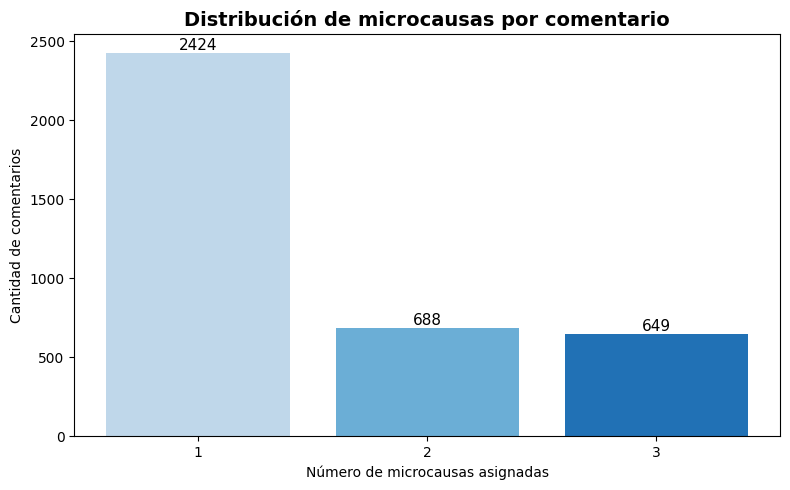

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

data = df["top_microcause_count"].value_counts().sort_index()

bars = plt.bar(
    data.index.astype(str),
    data.values,
    color=["#BFD7EA", "#6BAED6", "#2171B5"]
)

plt.title("Distribución de microcausas por comentario", fontsize=14, fontweight="bold")
plt.xlabel("Número de microcausas asignadas")
plt.ylabel("Cantidad de comentarios")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.savefig("grafico_topk_microcausas.png", dpi=300, bbox_inches="tight")
plt.show()

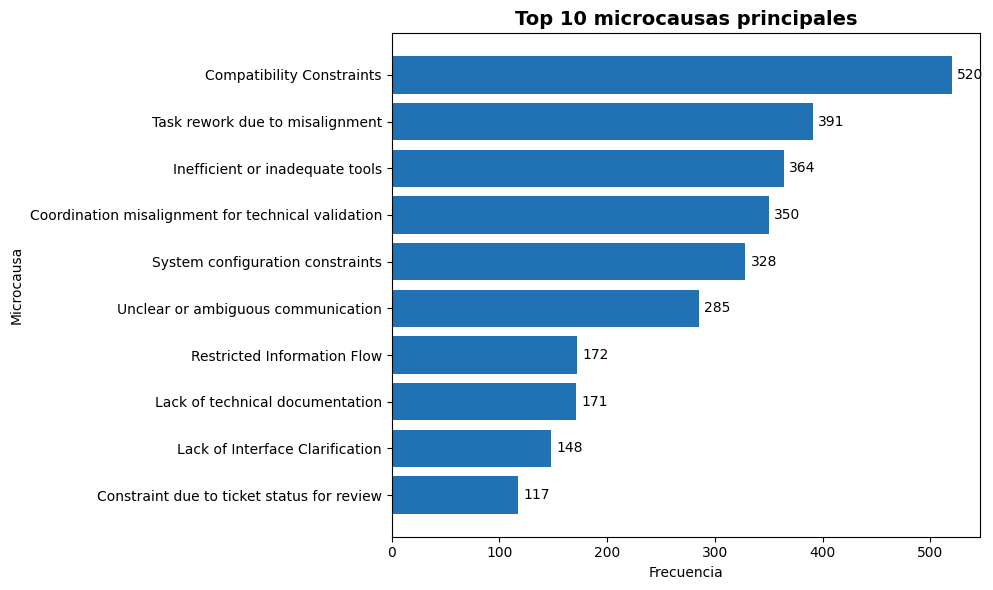

In [95]:
top_micro = df["primary_microcause_name"].value_counts().head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_micro.index[::-1],
    top_micro.values[::-1],
    color="#2171B5"
)

plt.title("Top 10 microcausas principales", fontsize=14, fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Microcausa")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("grafico_top10_microcausas.png", dpi=300, bbox_inches="tight")
plt.show()

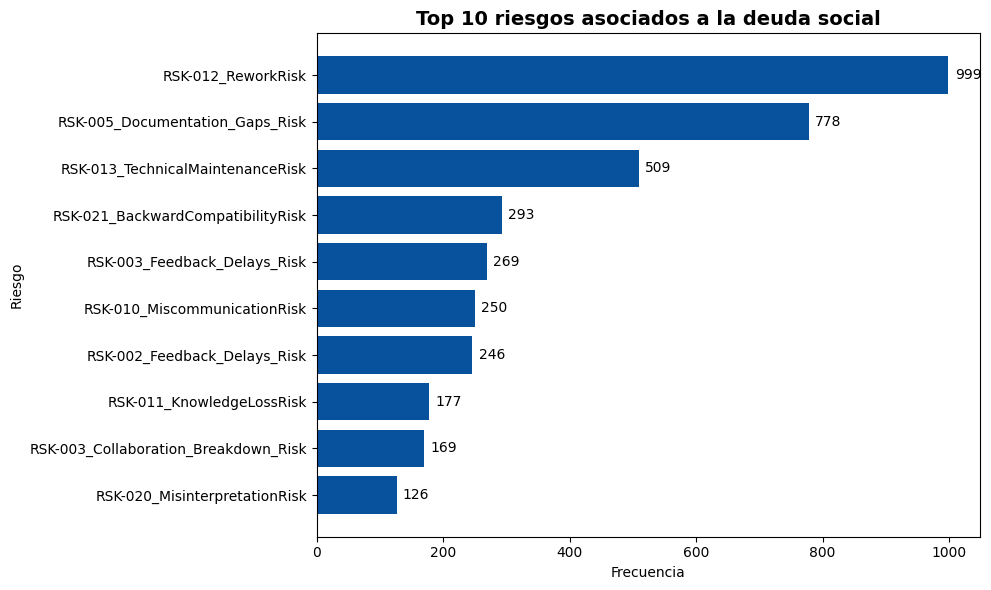

In [96]:
top_risk = risk_freq.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_risk.index[::-1],
    top_risk.values[::-1],
    color="#08519C"
)

plt.title("Top 10 riesgos asociados a la deuda social", fontsize=14, fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Riesgo")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("grafico_top10_riesgos.png", dpi=300, bbox_inches="tight")
plt.show()

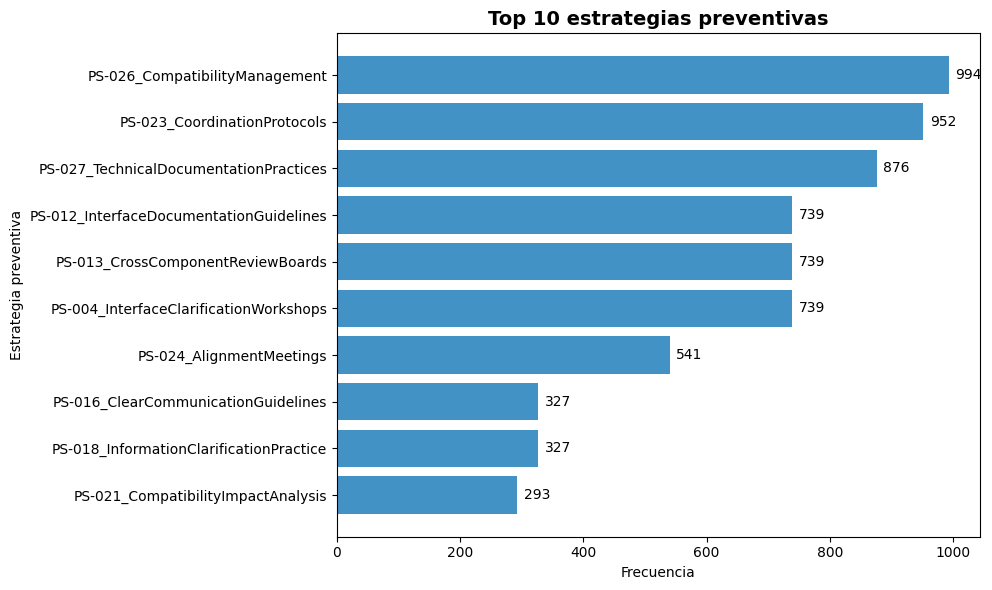

In [97]:
top_prev = strategy_freq.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_prev.index[::-1],
    top_prev.values[::-1],
    color="#4292C6"
)

plt.title("Top 10 estrategias preventivas", fontsize=14, fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Estrategia preventiva")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("grafico_top10_estrategias_preventivas.png", dpi=300, bbox_inches="tight")
plt.show()

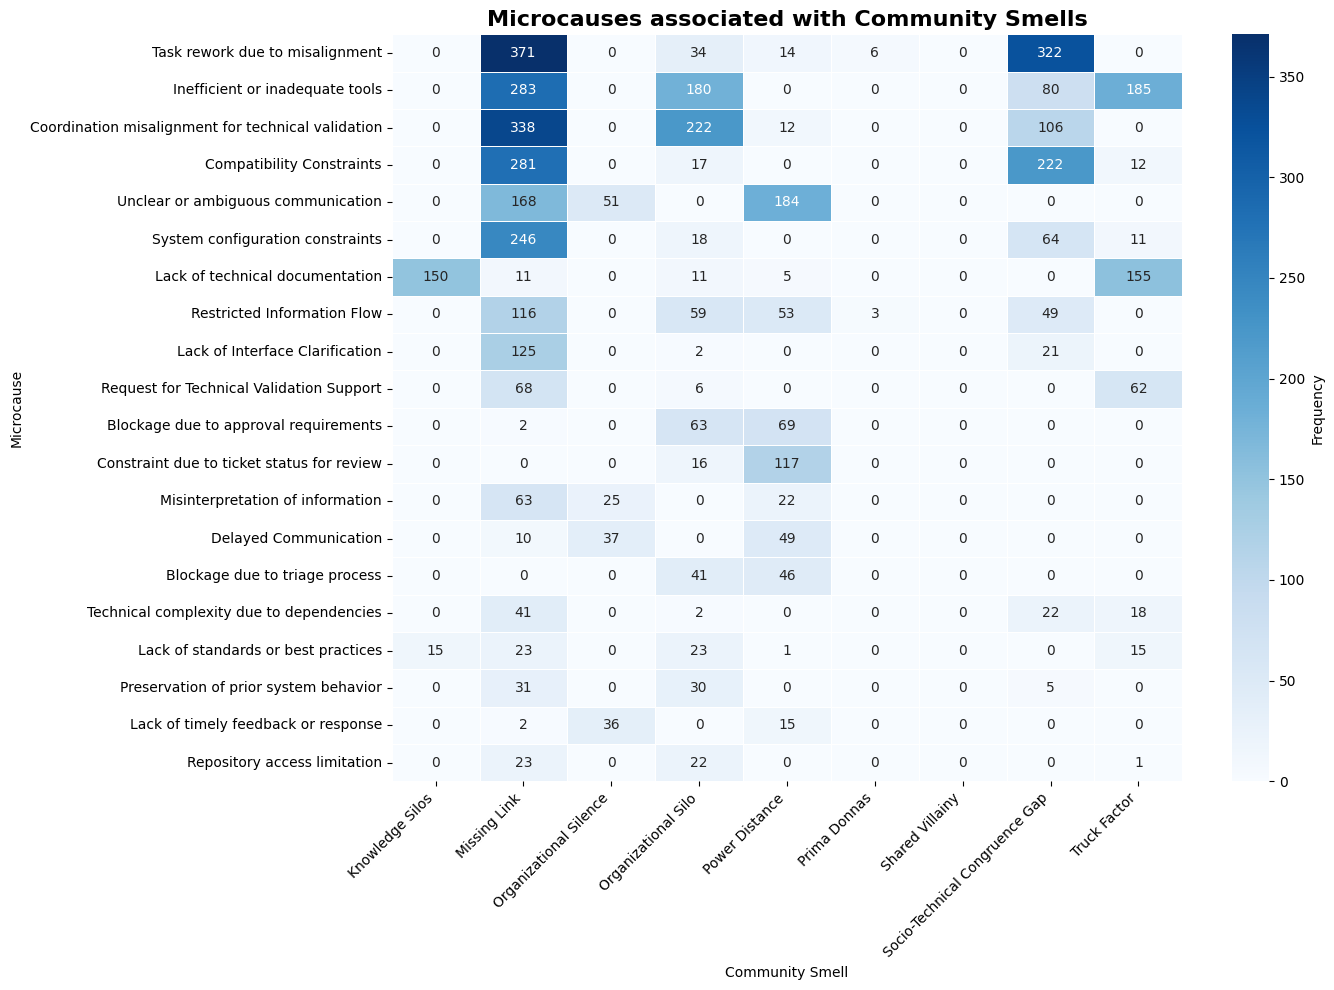

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar solo las 20 microcausas con mayor suma
top_microcauses = (
    matrix_micro_smell
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap_data = matrix_micro_smell.loc[top_microcauses]

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Frequency"}
)

plt.title(
    "Microcauses associated with Community Smells",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Community Smell")
plt.ylabel("Microcause")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_microcause_community_smell.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

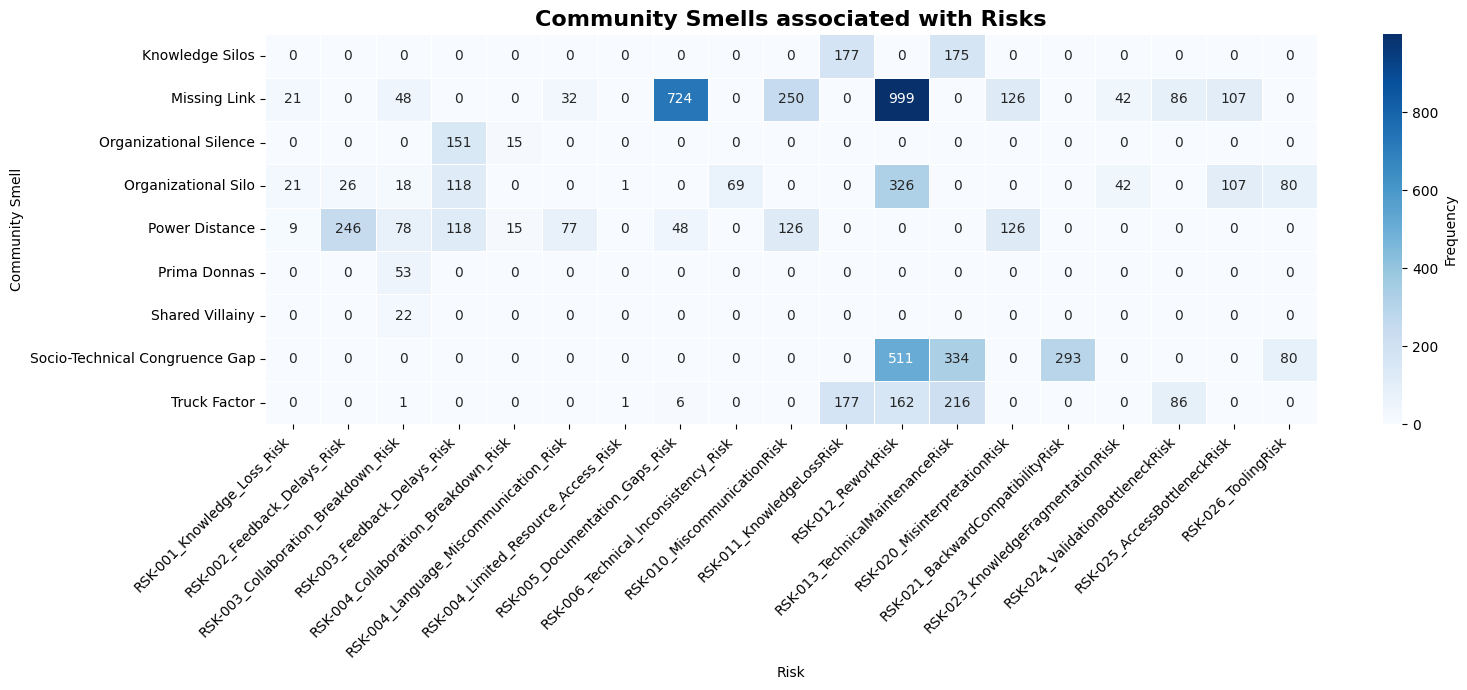

In [99]:
# Usar matriz del PASO 17
plt.figure(figsize=(16, 7))

sns.heatmap(
    matrix_smell_risk,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Frequency"}
)

plt.title(
    "Community Smells associated with Risks",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk")
plt.ylabel("Community Smell")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_community_smell_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
!pip install -U kaleido

In [101]:
import kaleido
print("Kaleido instalado correctamente")

Kaleido instalado correctamente


In [102]:
import plotly.graph_objects as go
import pandas as pd

# ============================================================
# Preparar relaciones para Sankey
# ============================================================

relations = []

for _, row in df.iterrows():

    macro = row["final_cause_for_analysis"]
    micro = row["primary_microcause_name"]

    smells = [
        s.strip()
        for s in str(row["community_smells"]).split("•")
        if s.strip() != ""
    ]

    risks = [
        r.strip()
        for r in str(row["risks"]).split("•")
        if r.strip() != ""
    ]

    for smell in smells:
        relations.append((macro, micro))

        relations.append((micro, smell))

        for risk in risks:
            relations.append((smell, risk))

relations_df = pd.DataFrame(
    relations,
    columns=["source", "target"]
)

relations_count = (
    relations_df
    .value_counts()
    .reset_index(name="value")
)

# Filtrar relaciones pequeñas para que el gráfico no quede saturado
relations_count = relations_count[
    relations_count["value"] >= 80
]

# Crear nodos
labels = pd.unique(
    relations_count[["source", "target"]].values.ravel()
).tolist()

label_to_id = {
    label: i
    for i, label in enumerate(labels)
}

sources = relations_count["source"].map(label_to_id)
targets = relations_count["target"].map(label_to_id)
values = relations_count["value"]

# ============================================================
# Sankey
# ============================================================

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=20,
                thickness=18,
                line=dict(color="black", width=0.3),
                label=labels,
                color="#9ECAE1"
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color="rgba(33, 113, 181, 0.35)"
            )
        )
    ]
)

fig.update_layout(
    title_text="Semantic Flow of Social Debt: Macrocauses, Microcauses, Community Smells and Risks",
    font_size=11,
    width=1300,
    height=850
)



fig.show()

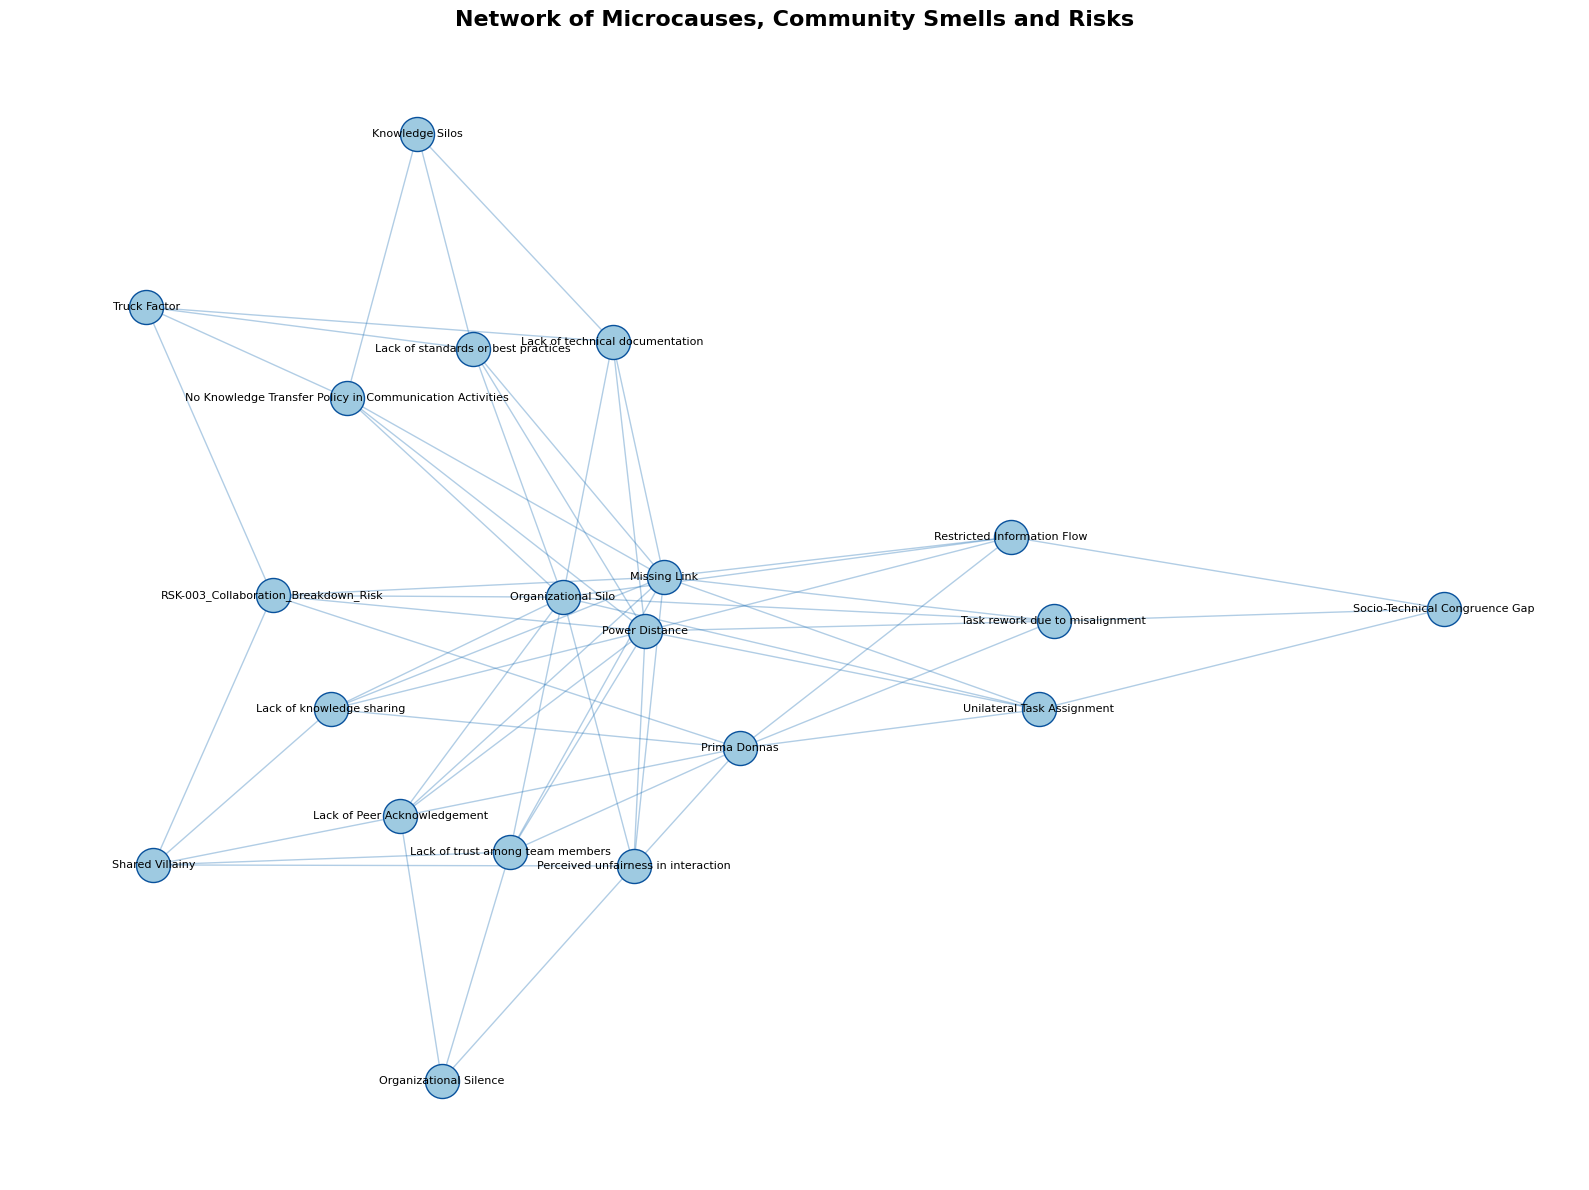

In [103]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Relaciones microcausa-community smell
for _, row in micro_smell_df.iterrows():
    G.add_edge(
        row["microcause"],
        row["community_smell"],
        weight=1
    )

# Relaciones community smell-risk
for _, row in df_smell_risk.iterrows():
    G.add_edge(
        row["community_smell"],
        row["risk"],
        weight=1
    )

# Filtrar nodos con grado alto para que sea legible
degree_dict = dict(G.degree())
important_nodes = [
    node for node, degree in degree_dict.items()
    if degree >= 5
]

G_sub = G.subgraph(important_nodes)

plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G_sub,
    k=0.35,
    seed=42
)

nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=600,
    node_color="#9ECAE1",
    edgecolors="#08519C"
)

nx.draw_networkx_edges(
    G_sub,
    pos,
    alpha=0.35,
    edge_color="#2171B5"
)

nx.draw_networkx_labels(
    G_sub,
    pos,
    font_size=8
)

plt.title(
    "Network of Microcauses, Community Smells and Risks",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "network_microcause_smell_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FASE III. VISUALIZACIÓN CIENTÍFICA DEL ECOSISTEMA DE DEUDA SOCIAL
Objetivo: generar gráficos publicables para representar patrones sociotécnicos.


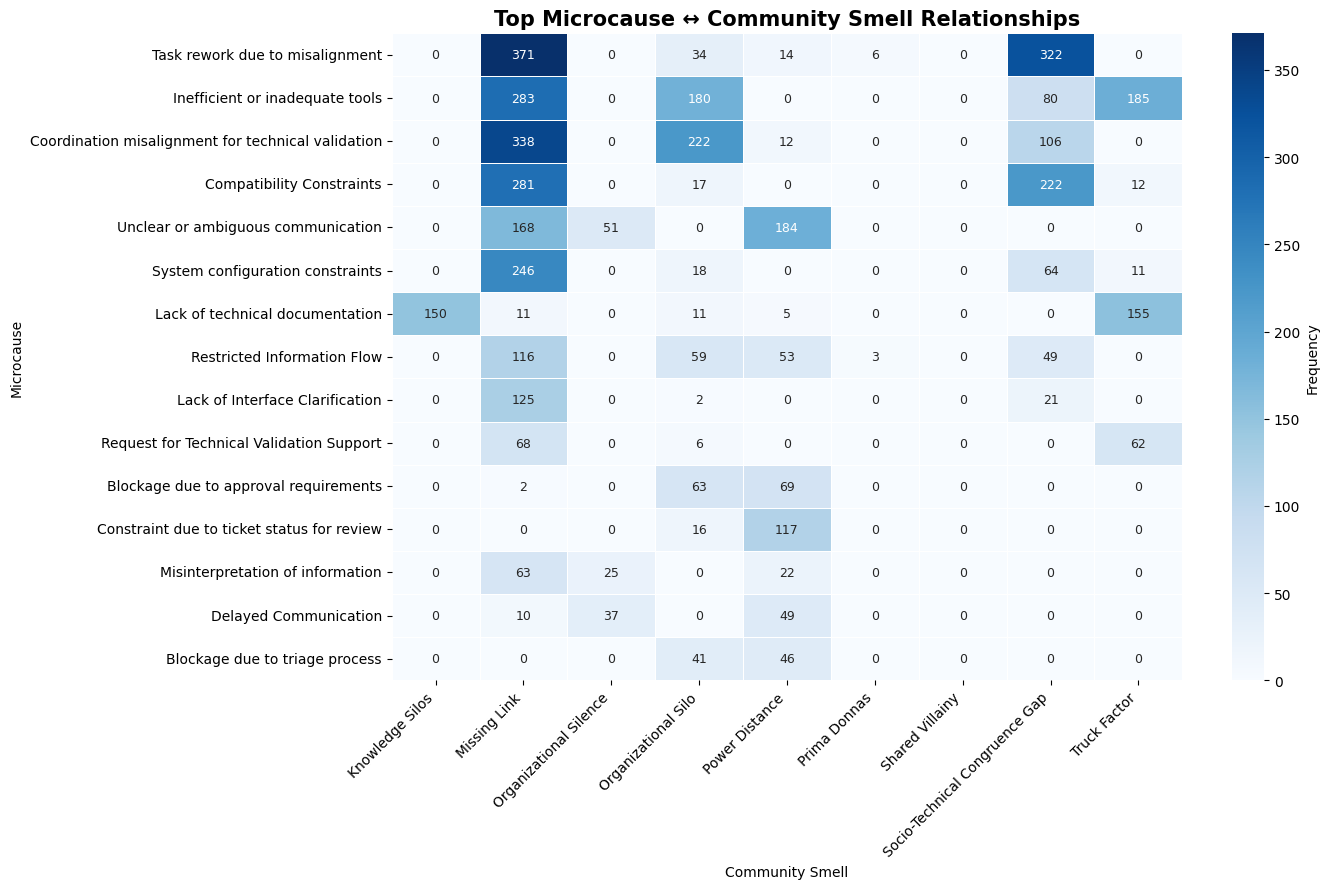

In [104]:
# ============================================================
# FASE III. VISUALIZACIÓN CIENTÍFICA DEL ECOSISTEMA DE DEUDA SOCIAL
# ============================================================

print("====================================================")
print("FASE III. VISUALIZACIÓN CIENTÍFICA DEL ECOSISTEMA DE DEUDA SOCIAL")
print("====================================================")
print("Objetivo: generar gráficos publicables para representar patrones sociotécnicos.")

# ============================================================
# PASO 23. HEATMAP MICROCAUSA ↔ COMMUNITY SMELL CON FRECUENCIAS
# ============================================================

# ============================================================
# HEATMAP FILTRADO: TOP 15 MICROCAUSAS ↔ COMMUNITY SMELL
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matrix = pd.read_excel(
    "matrix_microcause_community_smell.xlsx",
    index_col=0
)

# Seleccionar las 15 microcausas con mayor suma total
top_microcauses = (
    matrix.sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

matrix_top = matrix.loc[top_microcauses]

plt.figure(figsize=(14, 9))

sns.heatmap(
    matrix_top,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Frequency"},
    annot_kws={"size": 9}
)

plt.title(
    "Top Microcause ↔ Community Smell Relationships",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Community Smell")
plt.ylabel("Microcause")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_top15_microcause_community_smell.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

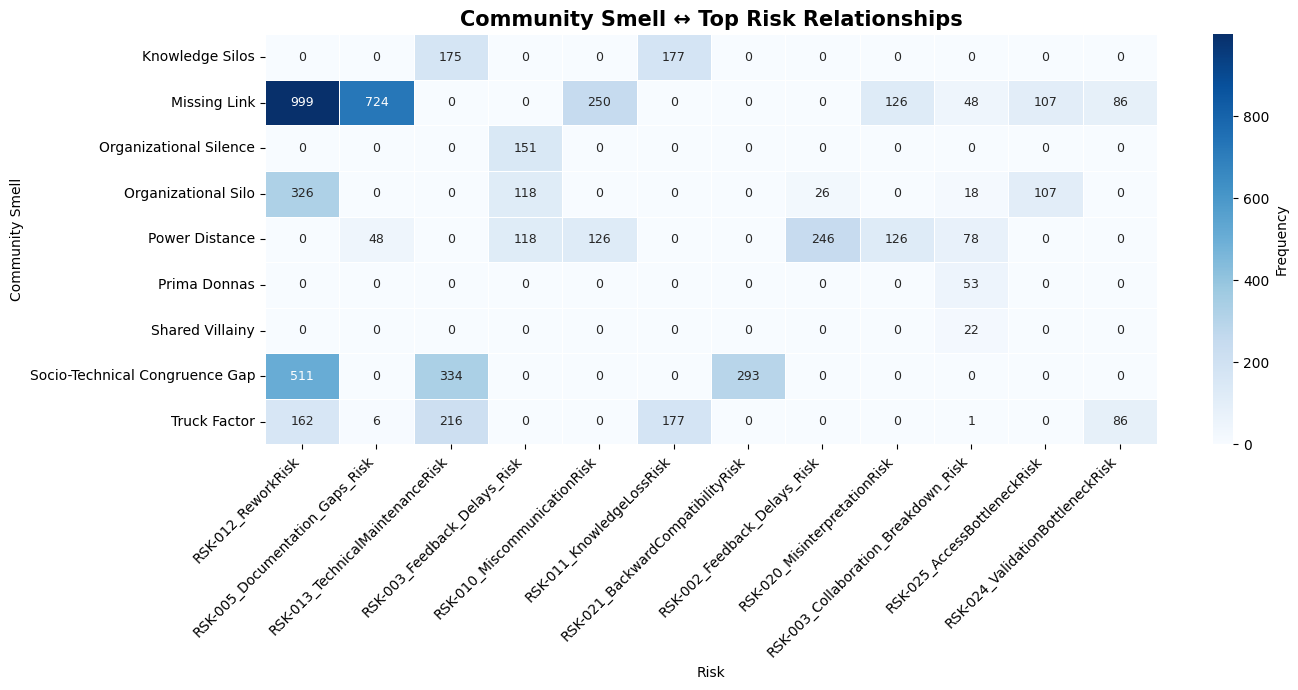

In [105]:
# ============================================================
# PASO 24. HEATMAP COMMUNITY SMELL ↔ RISK CON FRECUENCIAS
# ============================================================

# ============================================================
# HEATMAP FILTRADO: COMMUNITY SMELL ↔ TOP 12 RIESGOS
# ============================================================

matrix = pd.read_excel(
    "matrix_community_smell_risks.xlsx",
    index_col=0
)

# Seleccionar los 12 riesgos más frecuentes
top_risks = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
    .head(12)
    .index
)

matrix_top = matrix[top_risks]

plt.figure(figsize=(14, 7))

sns.heatmap(
    matrix_top,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Frequency"},
    annot_kws={"size": 9}
)

plt.title(
    "Community Smell ↔ Top Risk Relationships",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Risk")
plt.ylabel("Community Smell")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_community_smell_top12_risks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
# ============================================================
# FASE IV. DESCUBRIMIENTO DE CONOCIMIENTO
# ============================================================

print("====================================================")
print("FASE IV. DESCUBRIMIENTO DE CONOCIMIENTO")
print("====================================================")
print("Objetivo: sintetizar hallazgos relevantes derivados del modelo adaptativo.")

# ============================================================
# PASO 28. COMMUNITY SMELLS DOMINANTES
# ============================================================

import pandas as pd

matrix = pd.read_excel(
    "matrix_microcause_community_smell.xlsx",
    index_col=0
)

community_smell_totals = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
)

print("====================================================")
print("PASO 28. COMMUNITY SMELLS DOMINANTES")
print("====================================================")

display(
    community_smell_totals.to_frame("frequency")
)

community_smell_pct = (
    community_smell_totals /
    community_smell_totals.sum() * 100
).round(2)

print("\nPorcentaje:")
display(
    community_smell_pct.to_frame("percentage")
)

FASE IV. DESCUBRIMIENTO DE CONOCIMIENTO
Objetivo: sintetizar hallazgos relevantes derivados del modelo adaptativo.
PASO 28. COMMUNITY SMELLS DOMINANTES


,frequency
Missing Link,2309
Socio-Technical Congruence Gap,925
Organizational Silo,808
Power Distance,717
Truck Factor,474
Knowledge Silos,177
Organizational Silence,166
Prima Donnas,53
Shared Villainy,22



Porcentaje:


,percentage
Missing Link,40.86
Socio-Technical Congruence Gap,16.37
Organizational Silo,14.30
Power Distance,12.69
Truck Factor,8.39
Knowledge Silos,3.13
Organizational Silence,2.94
Prima Donnas,0.94
Shared Villainy,0.39


In [107]:
# ============================================================
# PASO 29. RIESGOS DOMINANTES
# ============================================================

matrix = pd.read_excel(
    "matrix_microcause_risks.xlsx",
    index_col=0
)

risk_totals = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
)

print("====================================================")
print("PASO 29. RIESGOS DOMINANTES")
print("====================================================")

display(
    risk_totals.to_frame("frequency")
)

PASO 29. RIESGOS DOMINANTES


,frequency
RSK-012_ReworkRisk,999
RSK-005_Documentation_Gaps_Risk,778
RSK-013_TechnicalMaintenanceRisk,509
RSK-021_BackwardCompatibilityRisk,293
RSK-003_Feedback_Delays_Risk,269
RSK-010_MiscommunicationRisk,250
RSK-002_Feedback_Delays_Risk,246
RSK-011_KnowledgeLossRisk,177
RSK-003_Collaboration_Breakdown_Risk,169
RSK-020_MisinterpretationRisk,126


In [108]:
# ============================================================
# PASO 30. ESTRATEGIAS PREVENTIVAS DOMINANTES
# ============================================================

matrix = pd.read_excel(
    "matrix_microcause_preventive_strategies.xlsx",
    index_col=0
)

strategy_totals = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
)

display(
    strategy_totals.head(20)
)

,0
PS-026_CompatibilityManagement,994
PS-023_CoordinationProtocols,952
PS-027_TechnicalDocumentationPractices,876
PS-004_InterfaceClarificationWorkshops,739
PS-012_InterfaceDocumentationGuidelines,739
PS-013_CrossComponentReviewBoards,739
PS-024_AlignmentMeetings,541
PS-016_ClearCommunicationGuidelines,327
PS-018_InformationClarificationPractice,327
PS-021_CompatibilityImpactAnalysis,293


In [109]:
# ============================================================
# PASO 31. ESTRATEGIAS CORRECTIVAS DOMINANTES
# ============================================================

matrix = pd.read_excel(
    "matrix_microcause_corrective_strategies.xlsx",
    index_col=0
)

strategy_totals = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
)

display(
    strategy_totals.head(20)
)

,0
CS-034_ResourceUseCorrection,1212
CS-028_TaskDeliveryRecoveryPlan,1054
STR-I-015_ChangeManagementTraining,701
STR-I-016_ChangeChampions,701
CS-029_EffortRealignmentReview,674
CS-PM-006_EffortAlignmentRecovery,674
CS-027_TaskConflictResolution,534
CS-033_ReworkReductionReview,511
CS-020_RestateAndClarifyMeaning,504
CS-021_TargetedCompatibilityValidation,293


In [110]:
# ============================================================
# PASO 32. RUTAS CRÍTICAS DEL MODELO ADAPTATIVO
# ============================================================

import pandas as pd

# --------------------------------------------------
# Community Smell dominante por microcausa
# --------------------------------------------------

smell_matrix = pd.read_excel(
    "matrix_microcause_community_smell.xlsx",
    index_col=0
)

top_smell_by_microcause = (
    smell_matrix.idxmax(axis=1)
)

# --------------------------------------------------
# Riesgo dominante por microcausa
# --------------------------------------------------

risk_matrix = pd.read_excel(
    "matrix_microcause_risks.xlsx",
    index_col=0
)

top_risk_by_microcause = (
    risk_matrix.idxmax(axis=1)
)

# --------------------------------------------------
# Estrategia preventiva dominante
# --------------------------------------------------

preventive_matrix = pd.read_excel(
    "matrix_microcause_preventive_strategies.xlsx",
    index_col=0
)

top_preventive = (
    preventive_matrix.idxmax(axis=1)
)

# --------------------------------------------------
# Construcción de rutas
# --------------------------------------------------

critical_paths = pd.DataFrame({
    "microcause": smell_matrix.index,
    "dominant_community_smell": top_smell_by_microcause.values,
    "dominant_risk": top_risk_by_microcause.values,
    "dominant_preventive_strategy": top_preventive.values
})

print("====================================================")
print("PASO 32. RUTAS CRÍTICAS")
print("====================================================")

display(
    critical_paths.head(20)
)

critical_paths.to_excel(
    "critical_paths_social_debt.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("critical_paths_social_debt.xlsx")

PASO 32. RUTAS CRÍTICAS


,microcause,dominant_community_smell,dominant_risk,dominant_preventive_strategy
0,Blockage due to approval requirements,Power Distance,RSK-003_Feedback_Delays_Risk,PS-026_ApprovalWorkflowPredefinition
1,Blockage due to triage process,Power Distance,RSK-002_Feedback_Delays_Risk,PS-001_StandardizedTaskHandoverProcess
2,Centralized Decision Making,Missing Link,RSK-012_ReworkRisk,PS-024_AlignmentMeetings
3,Compatibility Constraints,Missing Link,RSK-005_Documentation_Gaps_Risk,PS-026_CompatibilityManagement
4,Constraint due to ticket status for review,Power Distance,RSK-002_Feedback_Delays_Risk,PS-001_StandardizedTaskHandoverProcess
5,Coordination misalignment for technical validation,Missing Link,RSK-012_ReworkRisk,PS-023_CoordinationProtocols
6,Delayed Communication,Power Distance,RSK-002_Feedback_Delays_Risk,PS-017_TimelyFeedbackMechanism
7,Frequent Leadership Conflicts,Missing Link,RSK-003_Collaboration_Breakdown_Risk,PS-005_CrossTeamCoordinationMeetings
8,Inefficient or inadequate tools,Missing Link,RSK-012_ReworkRisk,PS-022_ClearValidationWorkflow
9,Inefficient organizational processes,Power Distance,RSK-003_Feedback_Delays_Risk,PS-026_ApprovalWorkflowPredefinition



Archivo exportado:
critical_paths_social_debt.xlsx


In [111]:
# ============================================================
# PASO 33. MICROCAUSAS ESTRUCTURALES
# ============================================================

import pandas as pd

smells = pd.read_excel(
    "matrix_microcause_community_smell.xlsx",
    index_col=0
)

risks = pd.read_excel(
    "matrix_microcause_risks.xlsx",
    index_col=0
)

effects = pd.read_excel(
    "matrix_microcause_effects.xlsx",
    index_col=0
)

structural_score = pd.DataFrame({
    "community_smells": (smells > 0).sum(axis=1),
    "risks": (risks > 0).sum(axis=1),
    "effects": (effects > 0).sum(axis=1)
})

structural_score["total_connections"] = (
    structural_score.sum(axis=1)
)

structural_score = (
    structural_score
    .sort_values(
        "total_connections",
        ascending=False
    )
)

print("====================================================")
print("PASO 33. MICROCAUSAS ESTRUCTURALES")
print("====================================================")

display(structural_score.head(20))

PASO 33. MICROCAUSAS ESTRUCTURALES


,community_smells,risks,effects,total_connections
microcause,,,,
Restricted Information Flow,5,4,18,27
Task rework due to misalignment,5,4,18,27
Coordination misalignment for technical validation,4,4,14,22
Unilateral Task Assignment,5,3,13,21
Lack of Task Discussion,4,3,12,19
Inefficient or inadequate tools,4,6,8,18
Compatibility Constraints,4,4,9,17
Technical complexity due to dependencies,4,4,9,17
No Knowledge Transfer Policy in Communication Activities,5,5,7,17


In [112]:
# ============================================================
# PASO 34. COMMUNITY SMELLS ESTRUCTURALES
# ============================================================

import pandas as pd

# Matrices ya exportadas
smell_risk = pd.read_excel(
    "matrix_community_smell_risks.xlsx",
    index_col=0
)

smell_preventive = pd.read_excel(
    "matrix_community_smell_preventive.xlsx",
    index_col=0
)

smell_corrective = pd.read_excel(
    "matrix_community_smell_corrective.xlsx",
    index_col=0
)

# Si ya tienes matrix_community_smell_effects.xlsx
smell_effects = pd.read_excel(
    "matrix_community_smell_effects.xlsx",
    index_col=0
)

smell_structural_score = pd.DataFrame({
    "effects": (smell_effects > 0).sum(axis=1),
    "risks": (smell_risk > 0).sum(axis=1),
    "preventive_strategies": (smell_preventive > 0).sum(axis=1),
    "corrective_strategies": (smell_corrective > 0).sum(axis=1)
})

smell_structural_score["total_connections"] = (
    smell_structural_score.sum(axis=1)
)

smell_structural_score = (
    smell_structural_score
    .sort_values("total_connections", ascending=False)
)

print("====================================================")
print("PASO 34. COMMUNITY SMELLS ESTRUCTURALES")
print("====================================================")

display(smell_structural_score)

smell_structural_score.to_excel(
    "community_smells_structural_score.xlsx"
)

print("\nArchivo exportado:")
print("community_smells_structural_score.xlsx")

PASO 34. COMMUNITY SMELLS ESTRUCTURALES


,effects,risks,preventive_strategies,corrective_strategies,total_connections
community_smell,,,,,
Power Distance,17,9,31,25,82
Missing Link,19,10,26,25,80
Organizational Silo,14,10,12,20,56
Truck Factor,9,7,13,11,40
Prima Donnas,7,1,9,13,30
Socio-Technical Congruence Gap,7,4,5,6,22
Shared Villainy,5,1,2,9,17
Organizational Silence,4,2,2,5,13
Knowledge Silos,3,2,2,3,10



Archivo exportado:
community_smells_structural_score.xlsx


In [113]:
# ============================================================
# PASO 35. CLUSTERS DE DEUDA SOCIAL
# ============================================================

import pandas as pd

cooc = pd.read_excel(
    "microcause_cooccurrence.xlsx"
)

print("====================================================")
print("PASO 35. CLUSTERS DE DEUDA SOCIAL")
print("====================================================")

top_clusters = (
    cooc
    .sort_values("frequency", ascending=False)
    .head(20)
)

display(top_clusters)

top_clusters.to_excel(
    "top_social_debt_clusters.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("top_social_debt_clusters.xlsx")

PASO 35. CLUSTERS DE DEUDA SOCIAL


,microcause_1,microcause_2,frequency
0,Compatibility Constraints,System configuration constraints,355
1,Coordination misalignment for technical validation,Task rework due to misalignment,292
2,Compatibility Constraints,Technical complexity due to dependencies,173
3,Compatibility Constraints,Lack of Interface Clarification,159
4,System configuration constraints,Technical complexity due to dependencies,159
5,Inefficient or inadequate tools,Request for Technical Validation Support,147
6,Restricted Information Flow,Task rework due to misalignment,118
7,Coordination misalignment for technical validation,Restricted Information Flow,110
8,Lack of Interface Clarification,System configuration constraints,100
9,Miscommunication In Task Handover,Task rework due to misalignment,99



Archivo exportado:
top_social_debt_clusters.xlsx


In [114]:
# ============================================================
# PASO 37. PUNTOS DE INTERVENCIÓN
# ============================================================

top_interventions = (
    structural_score
    .sort_values(
        "total_connections",
        ascending=False
    )
    .head(15)
)

print("====================================================")
print("PASO 37. PUNTOS DE INTERVENCIÓN")
print("====================================================")

display(top_interventions)

PASO 37. PUNTOS DE INTERVENCIÓN


,community_smells,risks,effects,total_connections
microcause,,,,
Restricted Information Flow,5,4,18,27
Task rework due to misalignment,5,4,18,27
Coordination misalignment for technical validation,4,4,14,22
Unilateral Task Assignment,5,3,13,21
Lack of Task Discussion,4,3,12,19
Inefficient or inadequate tools,4,6,8,18
Compatibility Constraints,4,4,9,17
Technical complexity due to dependencies,4,4,9,17
No Knowledge Transfer Policy in Communication Activities,5,5,7,17


In [115]:
# ============================================================
# PASO 36. CAMINOS DE PROPAGACIÓN MICROCAUSA → SMELL → RIESGO
# ============================================================

import pandas as pd

print("====================================================")
print("PASO 36. CAMINOS DE PROPAGACIÓN MICROCAUSA → SMELL → RIESGO")
print("====================================================")

relations = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    smells = [
        s.strip()
        for s in str(row["community_smells"]).split("•")
        if s.strip() != ""
    ]

    risks = [
        r.strip()
        for r in str(row["risks"]).split("•")
        if r.strip() != ""
    ]

    for smell in smells:
        for risk in risks:
            relations.append({
                "microcause": microcause,
                "community_smell": smell,
                "risk": risk
            })

paths_df = pd.DataFrame(relations)

critical_paths = (
    paths_df
    .value_counts(
        [
            "microcause",
            "community_smell",
            "risk"
        ]
    )
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

print("\nTop 30 caminos de propagación:")
display(
    critical_paths.head(30)
)

critical_paths.to_excel(
    "critical_paths_microcause_smell_risk.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("critical_paths_microcause_smell_risk.xlsx")

PASO 36. CAMINOS DE PROPAGACIÓN MICROCAUSA → SMELL → RIESGO

Top 30 caminos de propagación:


,microcause,community_smell,risk,frequency
0,Task rework due to misalignment,Missing Link,RSK-012_ReworkRisk,356
1,Coordination misalignment for technical validation,Missing Link,RSK-012_ReworkRisk,328
2,Task rework due to misalignment,Socio-Technical Congruence Gap,RSK-012_ReworkRisk,322
3,Compatibility Constraints,Missing Link,RSK-005_Documentation_Gaps_Risk,281
4,System configuration constraints,Missing Link,RSK-005_Documentation_Gaps_Risk,246
5,Compatibility Constraints,Socio-Technical Congruence Gap,RSK-013_TechnicalMaintenanceRisk,222
6,Coordination misalignment for technical validation,Organizational Silo,RSK-012_ReworkRisk,222
7,Compatibility Constraints,Socio-Technical Congruence Gap,RSK-021_BackwardCompatibilityRisk,210
8,Unclear or ambiguous communication,Missing Link,RSK-010_MiscommunicationRisk,168
9,Lack of technical documentation,Knowledge Silos,RSK-011_KnowledgeLossRisk,150



Archivo exportado:
critical_paths_microcause_smell_risk.xlsx


In [116]:
# ============================================================
# PASO 37. PUNTOS DE INTERVENCIÓN ESTRATÉGICOS
# ============================================================

top_interventions = (
    structural_score
    .sort_values(
        "total_connections",
        ascending=False
    )
)

print("====================================================")
print("PASO 37. PUNTOS DE INTERVENCIÓN")
print("====================================================")

display(
    top_interventions.head(20)
)

top_interventions.to_excel(
    "top_intervention_points.xlsx"
)

print("\nArchivo exportado:")
print("top_intervention_points.xlsx")

PASO 37. PUNTOS DE INTERVENCIÓN


,community_smells,risks,effects,total_connections
microcause,,,,
Restricted Information Flow,5,4,18,27
Task rework due to misalignment,5,4,18,27
Coordination misalignment for technical validation,4,4,14,22
Unilateral Task Assignment,5,3,13,21
Lack of Task Discussion,4,3,12,19
Inefficient or inadequate tools,4,6,8,18
Compatibility Constraints,4,4,9,17
Technical complexity due to dependencies,4,4,9,17
No Knowledge Transfer Policy in Communication Activities,5,5,7,17



Archivo exportado:
top_intervention_points.xlsx


In [117]:
# ============================================================
# PASO 38. PRIORIZACIÓN DE INTERVENCIONES
# ============================================================

import pandas as pd

# -------------------------------------------
# Frecuencia real
# -------------------------------------------

frequency = (
    df["primary_microcause_name"]
    .value_counts()
    .reset_index()
)

frequency.columns = [
    "microcause",
    "frequency"
]

# -------------------------------------------
# Structural score (Paso 37)
# -------------------------------------------

intervention = (
    top_interventions
    .reset_index()
)

intervention.columns = [
    "microcause",
    "community_smells",
    "risks",
    "effects",
    "total_connections"
]

# -------------------------------------------
# Combinar
# -------------------------------------------

priority = frequency.merge(
    intervention,
    on="microcause",
    how="left"
)

# -------------------------------------------
# Score adaptativo
# -------------------------------------------

priority["priority_score"] = (
    priority["frequency"]
    *
    priority["total_connections"]
)

priority = (
    priority
    .sort_values(
        "priority_score",
        ascending=False
    )
)

print("====================================================")
print("PASO 38. PRIORIZACIÓN DE INTERVENCIONES")
print("====================================================")

display(
    priority.head(20)
)

priority.to_excel(
    "adaptive_intervention_priority.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("adaptive_intervention_priority.xlsx")

PASO 38. PRIORIZACIÓN DE INTERVENCIONES


,microcause,frequency,community_smells,risks,effects,total_connections,priority_score
1,Task rework due to misalignment,391,5,4,18,27,10557
0,Compatibility Constraints,520,4,4,9,17,8840
3,Coordination misalignment for technical validation,350,4,4,14,22,7700
2,Inefficient or inadequate tools,364,4,6,8,18,6552
4,System configuration constraints,328,4,4,9,17,5576
6,Restricted Information Flow,172,5,4,18,27,4644
5,Unclear or ambiguous communication,285,3,5,7,15,4275
7,Lack of technical documentation,171,5,5,7,17,2907
8,Lack of Interface Clarification,148,3,4,8,15,2220
10,Misinterpretation of information,109,3,5,7,15,1635



Archivo exportado:
adaptive_intervention_priority.xlsx


In [120]:
# ============================================================
# FASE V. VALIDACIÓN MEDIANTE COMPETENCY QUESTIONS
# ============================================================

print("====================================================")
print("FASE V. VALIDACIÓN MEDIANTE COMPETENCY QUESTIONS")
print("====================================================")
print("Objetivo: responder las preguntas de competencia usando evidencia empírica del dataset.")

# ============================================================
# PASO 39. VALIDACIÓN EMPÍRICA DE CQ1
# ============================================================


cq1 = (
    matrix_micro_smell
    .sum(axis=0)
    .sort_values(ascending=False)
)

cq1 = cq1.reset_index()
cq1.columns = [
    "community_smell",
    "frequency"
]

display(cq1)

cq1.to_excel(
    "CQ1_community_smells.xlsx",
    index=False
)

print("\nInterpretación:")
print("Community smells más asociados a las")
print("microcausas identificadas en el dataset.")


FASE V. VALIDACIÓN MEDIANTE COMPETENCY QUESTIONS
Objetivo: responder las preguntas de competencia usando evidencia empírica del dataset.


,community_smell,frequency
0,Missing Link,2309
1,Socio-Technical Congruence Gap,925
2,Organizational Silo,808
3,Power Distance,717
4,Truck Factor,474
5,Knowledge Silos,177
6,Organizational Silence,166
7,Prima Donnas,53
8,Shared Villainy,22



Interpretación:
Community smells más asociados a las
microcausas identificadas en el dataset.


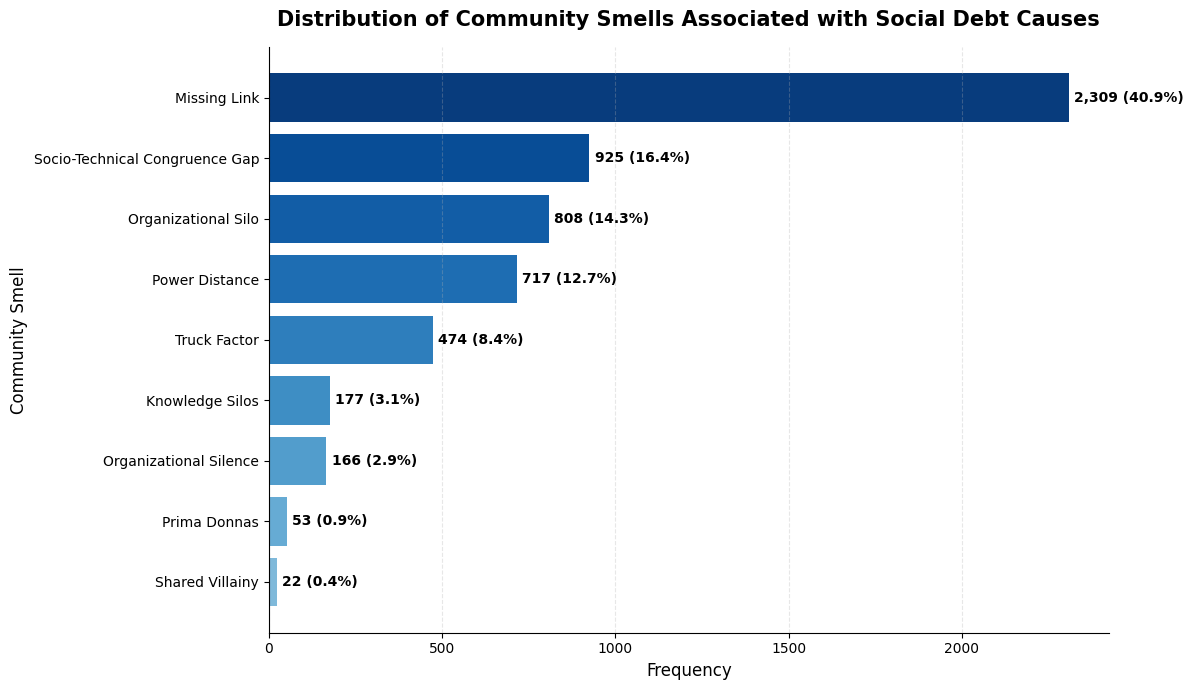

Figura exportada:
Figure_CQ1_Community_Smells.png
Figure_CQ1_Community_Smells.pdf


In [121]:
# ============================================================
# FIGURA CQ1
# DISTRIBUCIÓN DE COMMUNITY SMELLS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datos CQ1
cq1 = pd.DataFrame({
    "community_smell": [
        "Missing Link",
        "Socio-Technical Congruence Gap",
        "Organizational Silo",
        "Power Distance",
        "Truck Factor",
        "Knowledge Silos",
        "Organizational Silence",
        "Prima Donnas",
        "Shared Villainy"
    ],
    "frequency": [
        2309,
        925,
        808,
        717,
        474,
        177,
        166,
        53,
        22
    ]
})

# ------------------------------------------------
# porcentaje
# ------------------------------------------------

total = cq1["frequency"].sum()

cq1["percentage"] = (
    cq1["frequency"] / total * 100
).round(1)

# ------------------------------------------------
# ordenar
# ------------------------------------------------

cq1 = cq1.sort_values(
    "frequency",
    ascending=True
)

# ------------------------------------------------
# figura
# ------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12,7)
)

colors = plt.cm.Blues(
    np.linspace(
        0.45,
        0.95,
        len(cq1)
    )
)

bars = ax.barh(
    cq1["community_smell"],
    cq1["frequency"],
    color=colors
)

# ------------------------------------------------
# etiquetas
# ------------------------------------------------

for bar, freq, pct in zip(
    bars,
    cq1["frequency"],
    cq1["percentage"]
):

    ax.text(
        freq + 15,
        bar.get_y() + bar.get_height()/2,
        f"{freq:,} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------
# estilo Q1
# ------------------------------------------------

ax.set_title(
    "Distribution of Community Smells Associated with Social Debt Causes",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Frequency",
    fontsize=12
)

ax.set_ylabel(
    "Community Smell",
    fontsize=12
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ------------------------------------------------
# exportar
# ------------------------------------------------

plt.savefig(
    "Figure_CQ1_Community_Smells.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_CQ1_Community_Smells.pdf",
    bbox_inches="tight"
)

plt.show()

print("Figura exportada:")
print("Figure_CQ1_Community_Smells.png")
print("Figure_CQ1_Community_Smells.pdf")

In [124]:
# ============================================================
# RECONSTRUIR TABLA DE PRIORIZACIÓN PARA CQ2
# ============================================================

frequency = (
    df["primary_microcause_name"]
    .value_counts()
    .rename("frequency")
)

intervention = intervention.set_index("microcause")

intervention["frequency"] = frequency

intervention = intervention.fillna(0)

intervention["priority_score"] = (
    intervention["frequency"]
    *
    intervention["total_connections"]
)

intervention = (
    intervention
    .reset_index()
    .sort_values("priority_score", ascending=False)
)

display(intervention.head(20))

intervention.to_excel(
    "adaptive_intervention_priority.xlsx",
    index=False
)

,microcause,community_smells,risks,effects,total_connections,frequency,priority_score
1,Task rework due to misalignment,5,4,18,27,391,10557
6,Compatibility Constraints,4,4,9,17,520,8840
2,Coordination misalignment for technical validation,4,4,14,22,350,7700
5,Inefficient or inadequate tools,4,6,8,18,364,6552
10,System configuration constraints,4,4,9,17,328,5576
0,Restricted Information Flow,5,4,18,27,172,4644
17,Unclear or ambiguous communication,3,5,7,15,285,4275
9,Lack of technical documentation,5,5,7,17,171,2907
16,Lack of Interface Clarification,3,4,8,15,148,2220
18,Misinterpretation of information,3,5,7,15,109,1635


In [125]:
# ============================================================
# PASO 40. VALIDACIÓN EMPÍRICA DE CQ2
# ============================================================

print("====================================================")
print("PASO 40. VALIDACIÓN EMPÍRICA DE CQ2")
print("====================================================")

print(
    "¿Qué causas asociadas a factores sociotécnicos "
    "influyen en la aparición de deuda social?"
)

cq2 = intervention.copy()

cq2 = cq2.sort_values(
    "priority_score",
    ascending=False
)

display(
    cq2.head(20)
)

cq2.to_excel(
    "CQ2_influential_microcauses.xlsx"
)

print("\nArchivo exportado:")
print("CQ2_influential_microcauses.xlsx")

PASO 40. VALIDACIÓN EMPÍRICA DE CQ2
¿Qué causas asociadas a factores sociotécnicos influyen en la aparición de deuda social?


,microcause,community_smells,risks,effects,total_connections,frequency,priority_score
1,Task rework due to misalignment,5,4,18,27,391,10557
6,Compatibility Constraints,4,4,9,17,520,8840
2,Coordination misalignment for technical validation,4,4,14,22,350,7700
5,Inefficient or inadequate tools,4,6,8,18,364,6552
10,System configuration constraints,4,4,9,17,328,5576
0,Restricted Information Flow,5,4,18,27,172,4644
17,Unclear or ambiguous communication,3,5,7,15,285,4275
9,Lack of technical documentation,5,5,7,17,171,2907
16,Lack of Interface Clarification,3,4,8,15,148,2220
18,Misinterpretation of information,3,5,7,15,109,1635



Archivo exportado:
CQ2_influential_microcauses.xlsx


In [126]:
# ============================================================
# PASO 41A. TOP EFECTOS GLOBALES
# ============================================================

print("====================================================")
print("PASO 41A. TOP EFECTOS GLOBALES")
print("====================================================")

top_effects = (
    matrix_micro_effect
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

top_effects.columns = [
    "effect",
    "frequency"
]

display(top_effects.head(20))

top_effects.to_excel(
    "CQ3_top_effects.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ3_top_effects.xlsx")

PASO 41A. TOP EFECTOS GLOBALES


,effect,frequency
0,TEF-009_WastedTimeAndResources,1212
1,PME-003_DelaysInTaskDelivery,1036
2,IEF-008_ResistanceToChange,701
3,PME-006_MisalignedEfforts,674
4,PME-007_TaskRework,511
5,TEF-006_DuplicationOfEffort,511
6,TEF-002_CommunicationMisunderstandings,461
7,TEF-011_CompatibilityProblems,293
8,TEF-021_CompatibilityFailure,293
9,GEF-003_DifficultyInKnowledgeSharing,178



Archivo exportado:
CQ3_top_effects.xlsx


In [127]:
# ============================================================
# PASO 42. VALIDACIÓN EMPÍRICA DE CQ4
# ============================================================

print("====================================================")
print("PASO 42. VALIDACIÓN EMPÍRICA DE CQ4")
print("====================================================")

records = []

for micro in matrix_micro_effect.index:

    row = matrix_micro_effect.loc[micro]

    top_effects = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    for effect, freq in top_effects.items():

        records.append([
            micro,
            effect,
            freq
        ])

cq4 = pd.DataFrame(
    records,
    columns=[
        "microcause",
        "effect",
        "frequency"
    ]
)

cq4 = cq4.sort_values(
    "frequency",
    ascending=False
)

display(cq4.head(50))

cq4.to_excel(
    "CQ4_microcause_effects.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ4_microcause_effects.xlsx")

PASO 42. VALIDACIÓN EMPÍRICA DE CQ4


,microcause,effect,frequency
157,Task rework due to misalignment,PME-007_TaskRework,322
156,Task rework due to misalignment,TEF-009_WastedTimeAndResources,322
155,Task rework due to misalignment,TEF-006_DuplicationOfEffort,322
14,Compatibility Constraints,TEF-009_WastedTimeAndResources,267
13,Compatibility Constraints,IEF-008_ResistanceToChange,267
150,System configuration constraints,IEF-008_ResistanceToChange,242
151,System configuration constraints,TEF-009_WastedTimeAndResources,242
165,Unclear or ambiguous communication,TEF-002_CommunicationMisunderstandings,234
23,Coordination misalignment for technical validation,PME-006_MisalignedEfforts,227
24,Coordination misalignment for technical validation,PME-003_DelaysInTaskDelivery,222



Archivo exportado:
CQ4_microcause_effects.xlsx


In [128]:
# ============================================================
# PASO 43A. TOP ESTRATEGIAS CORRECTIVAS
# ============================================================

print("====================================================")
print("PASO 43A. TOP ESTRATEGIAS CORRECTIVAS")
print("====================================================")

top_corrective = (
    matrix_micro_corrective
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

top_corrective.columns = [
    "corrective_strategy",
    "frequency"
]

display(top_corrective.head(30))

top_corrective.to_excel(
    "CQ5_top_corrective_strategies.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ5_top_corrective_strategies.xlsx")

PASO 43A. TOP ESTRATEGIAS CORRECTIVAS


,corrective_strategy,frequency
0,CS-034_ResourceUseCorrection,1212
1,CS-028_TaskDeliveryRecoveryPlan,1054
2,STR-I-015_ChangeManagementTraining,701
3,STR-I-016_ChangeChampions,701
4,CS-029_EffortRealignmentReview,674
5,CS-PM-006_EffortAlignmentRecovery,674
6,CS-027_TaskConflictResolution,534
7,CS-033_ReworkReductionReview,511
8,CS-020_RestateAndClarifyMeaning,504
9,CS-021_TargetedCompatibilityValidation,293



Archivo exportado:
CQ5_top_corrective_strategies.xlsx


In [130]:
# ============================================================
# PASO 43B. MICROCAUSA -> ESTRATEGIA CORRECTIVA
# ============================================================

records = []

for micro in matrix_micro_corrective.index:

    row = matrix_micro_corrective.loc[micro]

    top_strategies = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    for strategy, freq in top_strategies.items():

        records.append([
            micro,
            strategy,
            freq
        ])

cq5 = pd.DataFrame(
    records,
    columns=[
        "microcause",
        "corrective_strategy",
        "frequency"
    ]
)

cq5 = cq5.sort_values(
    "frequency",
    ascending=False
)

display(cq5.head(50))

cq5.to_excel(
    "CQ5_microcause_corrective.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ5_microcause_corrective.xlsx")

,microcause,corrective_strategy,frequency
165,Task rework due to misalignment,CS-027_TaskConflictResolution,322
167,Task rework due to misalignment,CS-033_ReworkReductionReview,322
166,Task rework due to misalignment,CS-034_ResourceUseCorrection,322
17,Compatibility Constraints,CS-034_ResourceUseCorrection,267
16,Compatibility Constraints,STR-I-016_ChangeChampions,267
15,Compatibility Constraints,STR-I-015_ChangeManagementTraining,267
161,System configuration constraints,STR-I-016_ChangeChampions,242
162,System configuration constraints,CS-034_ResourceUseCorrection,242
160,System configuration constraints,STR-I-015_ChangeManagementTraining,242
175,Unclear or ambiguous communication,CS-020_RestateAndClarifyMeaning,234



Archivo exportado:
CQ5_microcause_corrective.xlsx


In [131]:
# ============================================================
# PASO 44A. TOP ESTRATEGIAS PREVENTIVAS
# ============================================================

print("====================================================")
print("PASO 44A. TOP ESTRATEGIAS PREVENTIVAS")
print("====================================================")

top_preventive = (
    matrix_micro_strategy
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

top_preventive.columns = [
    "preventive_strategy",
    "frequency"
]

display(top_preventive.head(30))

top_preventive.to_excel(
    "CQ6_top_preventive_strategies.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ6_top_preventive_strategies.xlsx")

PASO 44A. TOP ESTRATEGIAS PREVENTIVAS


,preventive_strategy,frequency
0,PS-026_CompatibilityManagement,994
1,PS-023_CoordinationProtocols,952
2,PS-027_TechnicalDocumentationPractices,876
3,PS-004_InterfaceClarificationWorkshops,739
4,PS-012_InterfaceDocumentationGuidelines,739
5,PS-013_CrossComponentReviewBoards,739
6,PS-024_AlignmentMeetings,541
7,PS-016_ClearCommunicationGuidelines,327
8,PS-018_InformationClarificationPractice,327
9,PS-021_CompatibilityImpactAnalysis,293



Archivo exportado:
CQ6_top_preventive_strategies.xlsx


In [132]:
# ============================================================
# PASO 44B. MICROCAUSA -> ESTRATEGIA PREVENTIVA
# ============================================================

records = []

for micro in matrix_micro_strategy.index:

    row = matrix_micro_strategy.loc[micro]

    top_strategies = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    for strategy, freq in top_strategies.items():

        records.append([
            micro,
            strategy,
            freq
        ])

cq6 = pd.DataFrame(
    records,
    columns=[
        "microcause",
        "preventive_strategy",
        "frequency"
    ]
)

cq6 = cq6.sort_values(
    "frequency",
    ascending=False
)

display(cq6.head(50))

cq6.to_excel(
    "CQ6_microcause_preventive.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ6_microcause_preventive.xlsx")

,microcause,preventive_strategy,frequency
14,Compatibility Constraints,PS-026_CompatibilityManagement,477
157,Task rework due to misalignment,PS-023_CoordinationProtocols,372
24,Coordination misalignment for technical validation,PS-023_CoordinationProtocols,339
152,System configuration constraints,PS-026_CompatibilityManagement,295
15,Compatibility Constraints,PS-004_InterfaceClarificationWorkshops,281
17,Compatibility Constraints,PS-012_InterfaceDocumentationGuidelines,281
16,Compatibility Constraints,PS-013_CrossComponentReviewBoards,281
18,Compatibility Constraints,PS-027_TechnicalDocumentationPractices,267
155,System configuration constraints,PS-012_InterfaceDocumentationGuidelines,246
153,System configuration constraints,PS-004_InterfaceClarificationWorkshops,246



Archivo exportado:
CQ6_microcause_preventive.xlsx


In [133]:
# ============================================================
# PASO 46. VALIDACIÓN EMPÍRICA DE CQ7
# ============================================================

cq7 = (
    matrix_micro_smell
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

cq7.columns = [
    "community_smell",
    "frequency"
]

display(cq7)

cq7.to_excel(
    "CQ7_community_smells.xlsx",
    index=False
)

,community_smell,frequency
0,Missing Link,2309
1,Socio-Technical Congruence Gap,925
2,Organizational Silo,808
3,Power Distance,717
4,Truck Factor,474
5,Knowledge Silos,177
6,Organizational Silence,166
7,Prima Donnas,53
8,Shared Villainy,22


In [134]:
# ============================================================
# PASO 47. VALIDACIÓN EMPÍRICA DE CQ8
# ============================================================

records = []

for smell in matrix_smell_effect.index:

    row = matrix_smell_effect.loc[smell]

    top_effects = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    for effect, freq in top_effects.items():

        records.append([
            smell,
            effect,
            freq
        ])

cq8 = pd.DataFrame(
    records,
    columns=[
        "community_smell",
        "effect",
        "frequency"
    ]
)

cq8 = cq8.sort_values(
    "frequency",
    ascending=False
)

display(cq8.head(50))

cq8.to_excel(
    "CQ8_smell_effects.xlsx",
    index=False
)

,community_smell,effect,frequency
3,Missing Link,TEF-009_WastedTimeAndResources,1212
4,Missing Link,IEF-008_ResistanceToChange,701
5,Missing Link,PME-006_MisalignedEfforts,674
6,Missing Link,PME-003_DelaysInTaskDelivery,635
7,Missing Link,PME-007_TaskRework,511
33,Socio-Technical Congruence Gap,TEF-006_DuplicationOfEffort,511
34,Socio-Technical Congruence Gap,TEF-009_WastedTimeAndResources,511
32,Socio-Technical Congruence Gap,PME-007_TaskRework,511
12,Organizational Silo,PME-003_DelaysInTaskDelivery,492
17,Power Distance,PME-003_DelaysInTaskDelivery,375


In [135]:
# ============================================================
# PASO 46. VALIDACIÓN EMPÍRICA DE CQ7
# ============================================================

print("====================================================")
print("PASO 46. VALIDACIÓN EMPÍRICA DE CQ7")
print("====================================================")

cq7 = (
    matrix_micro_smell
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

cq7.columns = [
    "community_smell",
    "frequency"
]

display(cq7)

cq7.to_excel(
    "CQ7_community_smells.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ7_community_smells.xlsx")

PASO 46. VALIDACIÓN EMPÍRICA DE CQ7


,community_smell,frequency
0,Missing Link,2309
1,Socio-Technical Congruence Gap,925
2,Organizational Silo,808
3,Power Distance,717
4,Truck Factor,474
5,Knowledge Silos,177
6,Organizational Silence,166
7,Prima Donnas,53
8,Shared Villainy,22



Archivo exportado:
CQ7_community_smells.xlsx


In [136]:
# ============================================================
# PASO 47. VALIDACIÓN EMPÍRICA DE CQ8
# ============================================================

print("====================================================")
print("PASO 47. VALIDACIÓN EMPÍRICA DE CQ8")
print("====================================================")

records = []

for smell in matrix_smell_effect.index:

    row = matrix_smell_effect.loc[smell]

    top_effects = (
        row[row > 0]
        .sort_values(ascending=False)
        .head(5)
    )

    for effect, freq in top_effects.items():

        records.append([
            smell,
            effect,
            freq
        ])

cq8 = pd.DataFrame(
    records,
    columns=[
        "community_smell",
        "effect",
        "frequency"
    ]
)

cq8 = cq8.sort_values(
    "frequency",
    ascending=False
)

display(cq8.head(50))

cq8.to_excel(
    "CQ8_smell_effects.xlsx",
    index=False
)

print("\nArchivo exportado:")
print("CQ8_smell_effects.xlsx")

PASO 47. VALIDACIÓN EMPÍRICA DE CQ8


,community_smell,effect,frequency
3,Missing Link,TEF-009_WastedTimeAndResources,1212
4,Missing Link,IEF-008_ResistanceToChange,701
5,Missing Link,PME-006_MisalignedEfforts,674
6,Missing Link,PME-003_DelaysInTaskDelivery,635
7,Missing Link,PME-007_TaskRework,511
33,Socio-Technical Congruence Gap,TEF-006_DuplicationOfEffort,511
34,Socio-Technical Congruence Gap,TEF-009_WastedTimeAndResources,511
32,Socio-Technical Congruence Gap,PME-007_TaskRework,511
12,Organizational Silo,PME-003_DelaysInTaskDelivery,492
17,Power Distance,PME-003_DelaysInTaskDelivery,375



Archivo exportado:
CQ8_smell_effects.xlsx


In [137]:
# ============================================================
# PASO 48. VALIDACIÓN DE CQ9 - INDICADORES POR MICROCAUSA
# ============================================================

print("====================================================")
print("PASO 48. VALIDACIÓN DE CQ9 - INDICADORES")
print("====================================================")

records = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    indicators = [
        ind.strip()
        for ind in str(row["indicators"]).split("•")
        if ind.strip() != ""
    ]

    for indicator in indicators:

        records.append({
            "microcause": microcause,
            "indicator": indicator
        })

cq9_df = pd.DataFrame(records)

cq9 = (
    cq9_df
    .value_counts(["microcause", "indicator"])
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

display(cq9.head(50))

cq9.to_excel(
    "CQ9_microcause_indicators.xlsx",
    index=False
)

PASO 48. VALIDACIÓN DE CQ9 - INDICADORES


,microcause,indicator,frequency
0,Task rework due to misalignment,IND-012_TaskAlignmentLevel,356
1,Coordination misalignment for technical validation,IND-012_TaskAlignmentLevel,328
2,Compatibility Constraints,IND-004_Responsibility_Overlap_Index,281
3,System configuration constraints,IND-004_Responsibility_Overlap_Index,246
4,Compatibility Constraints,IND-013_DocumentationCompleteness,222
5,Compatibility Constraints,IND-021_CompatibilityMentions,210
6,Lack of technical documentation,IND-013_DocumentationCompleteness,149
7,Inefficient or inadequate tools,IND-012_TaskAlignmentLevel,133
8,Lack of Interface Clarification,IND-004_Responsibility_Overlap_Index,125
9,Unclear or ambiguous communication,IND-010_CommunicationClarityLevel,118


In [138]:
# ============================================================
# PASO 49. VALIDACIÓN DE CQ10 - MÉTRICAS POR MICROCAUSA
# ============================================================

print("====================================================")
print("PASO 49. VALIDACIÓN DE CQ10 - MÉTRICAS")
print("====================================================")

records = []

for _, row in df.iterrows():

    microcause = row["primary_microcause_name"]

    metrics = [
        metric.strip()
        for metric in str(row["metrics"]).split("•")
        if metric.strip() != ""
    ]

    for metric in metrics:

        records.append({
            "microcause": microcause,
            "metric": metric
        })

cq10_df = pd.DataFrame(records)

cq10 = (
    cq10_df
    .value_counts(["microcause", "metric"])
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

display(cq10.head(50))

cq10.to_excel(
    "CQ10_microcause_metrics.xlsx",
    index=False
)

PASO 49. VALIDACIÓN DE CQ10 - MÉTRICAS


,microcause,metric,frequency
0,Task rework due to misalignment,MTR-012_TaskAlignmentScore,356
1,Coordination misalignment for technical validation,MTR-012_TaskAlignmentScore,328
2,Compatibility Constraints,MTR-006_Information_Disconnect_Index,281
3,System configuration constraints,MTR-006_Information_Disconnect_Index,246
4,Compatibility Constraints,MTR-013_DocumentationCoverage,222
5,Lack of technical documentation,MTR-013_DocumentationCoverage,149
6,Inefficient or inadequate tools,MTR-012_TaskAlignmentScore,133
7,Lack of Interface Clarification,MTR-006_Information_Disconnect_Index,125
8,Unclear or ambiguous communication,MTR-020_ClarificationRequestRate,118
9,Unclear or ambiguous communication,MTR-010_ClarityScore,118


In [139]:
# ============================================================
# PASO 50. TABLA MAESTRA DE VALIDACIÓN DE CQs
# ============================================================

cq_summary = pd.DataFrame([

["CQ1",
 "Which community smells are associated with socio-technical factors?",
 "Community Smells",
 "CQ1_community_smells.xlsx",
 "Validated"],

["CQ2",
 "Which causes influence social debt?",
 "Priority Microcauses",
 "CQ2_influential_microcauses.xlsx",
 "Validated"],

["CQ3",
 "Which socio-technical factors are affected?",
 "Effects and Risks",
 "CQ3_top_effects.xlsx / CQ3_top_risks.xlsx",
 "Validated"],

["CQ4",
 "What effects does a cause produce?",
 "Microcause → Effect",
 "CQ4_microcause_effects.xlsx",
 "Validated"],

["CQ5",
 "Which corrective strategies are associated with effects?",
 "Microcause → Corrective Strategy",
 "CQ5_microcause_corrective.xlsx",
 "Validated"],

["CQ6",
 "Which preventive strategies can be applied?",
 "Microcause → Preventive Strategy",
 "CQ6_microcause_preventive.xlsx",
 "Validated"],

["CQ7",
 "Which community smells are associated with causes?",
 "Community Smells",
 "CQ7_community_smells.xlsx",
 "Validated"],

["CQ8",
 "What negative effects does a community smell generate?",
 "Smell → Effect",
 "CQ8_smell_effects.xlsx",
 "Validated"],

["CQ9",
 "Which indicators detect a cause?",
 "Cause → Indicator",
 "CQ9_microcause_indicators.xlsx",
 "Validated"],

["CQ10",
 "Which metrics quantify the impact of a cause?",
 "Cause → Metric",
 "CQ10_microcause_metrics.xlsx",
 "Validated"]

],
columns=[
    "CQ",
    "Question",
    "Evidence",
    "Artifact",
    "Status"
])

display(cq_summary)

cq_summary.to_excel(
    "CQ_validation_summary.xlsx",
    index=False
)

print("Archivo exportado:")
print("CQ_validation_summary.xlsx")

,CQ,Question,Evidence,Artifact,Status
0,CQ1,Which community smells are associated with socio-technical factors?,Community Smells,CQ1_community_smells.xlsx,Validated
1,CQ2,Which causes influence social debt?,Priority Microcauses,CQ2_influential_microcauses.xlsx,Validated
2,CQ3,Which socio-technical factors are affected?,Effects and Risks,CQ3_top_effects.xlsx / CQ3_top_risks.xlsx,Validated
3,CQ4,What effects does a cause produce?,Microcause → Effect,CQ4_microcause_effects.xlsx,Validated
4,CQ5,Which corrective strategies are associated with effects?,Microcause → Corrective Strategy,CQ5_microcause_corrective.xlsx,Validated
5,CQ6,Which preventive strategies can be applied?,Microcause → Preventive Strategy,CQ6_microcause_preventive.xlsx,Validated
6,CQ7,Which community smells are associated with causes?,Community Smells,CQ7_community_smells.xlsx,Validated
7,CQ8,What negative effects does a community smell generate?,Smell → Effect,CQ8_smell_effects.xlsx,Validated
8,CQ9,Which indicators detect a cause?,Cause → Indicator,CQ9_microcause_indicators.xlsx,Validated
9,CQ10,Which metrics quantify the impact of a cause?,Cause → Metric,CQ10_microcause_metrics.xlsx,Validated


Archivo exportado:
CQ_validation_summary.xlsx


In [140]:
# ============================================================
# FASE VI. CONSTRUCCIÓN DEL MODELO ADAPTATIVO FINAL
# ============================================================

print("====================================================")
print("FASE VI. CONSTRUCCIÓN DEL MODELO ADAPTATIVO FINAL")
print("====================================================")
print("Objetivo: construir reglas y rutas de inferencia para soporte a decisiones sobre deuda social.")

# ============================================================
# PASO 50. TABLA MAESTRA DE VALIDACIÓN DE CQs
# ============================================================

cq_summary = pd.DataFrame([

["CQ1",
 "Which community smells are associated with socio-technical factors?",
 "Community Smells",
 "CQ1_community_smells.xlsx",
 "Validated"],

["CQ2",
 "Which causes influence social debt?",
 "Priority Microcauses",
 "CQ2_influential_microcauses.xlsx",
 "Validated"],

["CQ3",
 "Which socio-technical factors are affected?",
 "Effects and Risks",
 "CQ3_top_effects.xlsx / CQ3_top_risks.xlsx",
 "Validated"],

["CQ4",
 "What effects does a cause produce?",
 "Microcause → Effect",
 "CQ4_microcause_effects.xlsx",
 "Validated"],

["CQ5",
 "Which corrective strategies are associated with effects?",
 "Microcause → Corrective Strategy",
 "CQ5_microcause_corrective.xlsx",
 "Validated"],

["CQ6",
 "Which preventive strategies can be applied?",
 "Microcause → Preventive Strategy",
 "CQ6_microcause_preventive.xlsx",
 "Validated"],

["CQ7",
 "Which community smells are associated with causes?",
 "Community Smells",
 "CQ7_community_smells.xlsx",
 "Validated"],

["CQ8",
 "What negative effects does a community smell generate?",
 "Smell → Effect",
 "CQ8_smell_effects.xlsx",
 "Validated"],

["CQ9",
 "Which indicators detect a cause?",
 "Cause → Indicator",
 "CQ9_microcause_indicators.xlsx",
 "Validated"],

["CQ10",
 "Which metrics quantify the impact of a cause?",
 "Cause → Metric",
 "CQ10_microcause_metrics.xlsx",
 "Validated"]

],
columns=[
    "CQ",
    "Question",
    "Evidence",
    "Artifact",
    "Status"
])

display(cq_summary)

cq_summary.to_excel(
    "CQ_validation_summary.xlsx",
    index=False
)

print("Archivo exportado:")
print("CQ_validation_summary.xlsx")

FASE VI. CONSTRUCCIÓN DEL MODELO ADAPTATIVO FINAL
Objetivo: construir reglas y rutas de inferencia para soporte a decisiones sobre deuda social.


,CQ,Question,Evidence,Artifact,Status
0,CQ1,Which community smells are associated with socio-technical factors?,Community Smells,CQ1_community_smells.xlsx,Validated
1,CQ2,Which causes influence social debt?,Priority Microcauses,CQ2_influential_microcauses.xlsx,Validated
2,CQ3,Which socio-technical factors are affected?,Effects and Risks,CQ3_top_effects.xlsx / CQ3_top_risks.xlsx,Validated
3,CQ4,What effects does a cause produce?,Microcause → Effect,CQ4_microcause_effects.xlsx,Validated
4,CQ5,Which corrective strategies are associated with effects?,Microcause → Corrective Strategy,CQ5_microcause_corrective.xlsx,Validated
5,CQ6,Which preventive strategies can be applied?,Microcause → Preventive Strategy,CQ6_microcause_preventive.xlsx,Validated
6,CQ7,Which community smells are associated with causes?,Community Smells,CQ7_community_smells.xlsx,Validated
7,CQ8,What negative effects does a community smell generate?,Smell → Effect,CQ8_smell_effects.xlsx,Validated
8,CQ9,Which indicators detect a cause?,Cause → Indicator,CQ9_microcause_indicators.xlsx,Validated
9,CQ10,Which metrics quantify the impact of a cause?,Cause → Metric,CQ10_microcause_metrics.xlsx,Validated


Archivo exportado:
CQ_validation_summary.xlsx
